## __Phase 3: Experiments__

### __Import packages__

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import numpy as np
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split

from scripts.experiments.experiment_01 import * 
from scripts.visualization.map_vessel_routes_v2 import * 

### __Import data__

In [2]:
df_AIS = pd.read_pickle("../scripts/test_scripts/AIS_sample_no_RF_5000.pkl") 
df_AIS_stats = pd.read_pickle("../scripts/test_scripts/statistics_sample_5000_1.pkl").reset_index(drop=True)
df_train_set = pd.read_pickle("../scripts/test_scripts/train_data_sample_5000.pkl") 
df_AIS_stats

,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight
0,"(354751000, 15)",359,729.383333,8.422928,0.13800,0.45217,122.243017,62.766426,0.154844,0.208307,0.625887,0.114460,0.787666,0.073953,-0.243298,0.097410,5.472008,3.927495
1,"(636022462, 18)",420,522.983333,21.758160,1.07070,1.49433,74.890215,24.089990,0.453157,0.152429,0.674577,0.063200,0.820132,0.044274,-0.200176,0.065951,5.982846,4.462511
2,"(538006167, 8)",1979,2885.350000,21.766905,4.21119,1.47923,87.523256,48.923027,0.437884,0.324976,0.651667,0.087826,0.804815,0.062766,-0.221287,0.100114,10.731568,14.627334
3,"(378111467, 37)",7,19.483333,15.285804,0.00725,0.04047,194.833333,57.045304,0.828583,0.273608,0.487268,0.247994,0.681854,0.149476,-0.404544,0.202816,4.394124,2.999756
4,"(266261000, 40)",1032,1430.883333,19.719140,2.34188,0.97944,83.271581,40.568604,0.365091,0.232925,0.670661,0.074051,0.817608,0.046674,-0.203087,0.059355,7.358261,6.293801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,"(304010766, 9)",8,30.433333,18.294282,0.05729,0.06365,260.857143,151.843591,1.328924,0.777603,0.419125,0.315532,0.604810,0.230932,-0.580362,0.400308,4.816718,3.334022
4996,"(636022893, 72)",282,334.900000,30.001334,1.49294,0.21673,71.508897,39.369687,0.596864,0.335970,0.661928,0.073476,0.811296,0.061051,-0.214284,0.119689,6.647083,5.268633
4997,"(577366000, 103)",186,258.350000,12.791165,0.12993,0.34185,83.789189,50.531349,0.250805,0.137301,0.695892,0.085279,0.832161,0.058307,-0.186887,0.085323,4.469045,3.056471
4998,"(636016243, 7)",9,16.683333,19.806503,0.02459,0.04403,125.125000,42.753237,0.689224,0.237470,0.584545,0.188821,0.756460,0.110967,-0.289376,0.141910,3.365191,2.319375


In [3]:
df_AIS.head()

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3


In [4]:
df_AIS_stats.head()

,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight
0,"(354751000, 15)",359,729.383333,8.422928,0.13800,0.45217,122.243017,62.766426,0.154844,0.208307,0.625887,0.114460,0.787666,0.073953,-0.243298,0.097410,5.472008,3.927495
1,"(636022462, 18)",420,522.983333,21.758160,1.07070,1.49433,74.890215,24.089990,0.453157,0.152429,0.674577,0.063200,0.820132,0.044274,-0.200176,0.065951,5.982846,4.462511
2,"(538006167, 8)",1979,2885.350000,21.766905,4.21119,1.47923,87.523256,48.923027,0.437884,0.324976,0.651667,0.087826,0.804815,0.062766,-0.221287,0.100114,10.731568,14.627334
3,"(378111467, 37)",7,19.483333,15.285804,0.00725,0.04047,194.833333,57.045304,0.828583,0.273608,0.487268,0.247994,0.681854,0.149476,-0.404544,0.202816,4.394124,2.999756
4,"(266261000, 40)",1032,1430.883333,19.719140,2.34188,0.97944,83.271581,40.568604,0.365091,0.232925,0.670661,0.074051,0.817608,0.046674,-0.203087,0.059355,7.358261,6.293801


In [5]:
df_train_set.head()

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
382,"(205717000, 3)",3,205717000,2024-01-01 03:40:23,NaT,NaT,None,None,begin
4,"(205717000, 3)",3,205717000,2024-01-01 03:40:24,2024-01-01 03:40:24,NaT,"[46.89339, -125.42151]",None,AIS
5,"(205717000, 3)",3,205717000,2024-01-01 03:44:15,2024-01-01 03:44:15,NaT,"[46.89344, -125.39996]",None,AIS
6,"(205717000, 3)",3,205717000,2024-01-01 03:45:33,2024-01-01 03:45:33,NaT,"[46.8935, -125.39274]",None,AIS
7,"(205717000, 3)",3,205717000,2024-01-01 03:46:39,2024-01-01 03:46:39,NaT,"[46.89348, -125.38572]",None,AIS


### __Preselection__

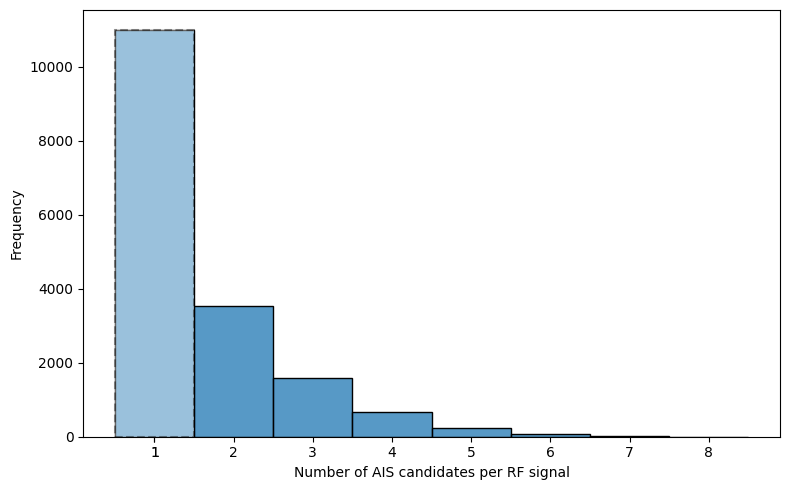

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

df_preselection = pd.read_pickle("../scripts/test_scripts/AIS_RF_preselection_df_time_window_6km.pkl")

df_preselection_multimatch = df_preselection.groupby(['RF_track_id','RF_signal_id']).filter(lambda x: x['AIS_track_id'].count() > 1)
df_preselection_multimatch = df_preselection_multimatch.reset_index(drop=True)

# Compute counts per RF signal
counts = (
    df_preselection
    .groupby(['RF_track_id', 'RF_signal_id'])
    .size()
    .reset_index(name='count')
)


# Set bin width (e.g., 1)
binwidth = 1

# Plot histogram with seaborn
plt.figure(figsize=(8, 5))
ax = sns.histplot(counts['count'], binwidth=binwidth, edgecolor='black', color="tab:blue")

# Get the first patch (bar)
first_patch = ax.patches[0]
first_bin_left = first_patch.get_x()
first_bin_width = first_patch.get_width()
first_bar_height = first_patch.get_height()

# Draw transparent rectangle over the first bar
ax.add_patch(
    patches.Rectangle(
        (first_bin_left, 0),
        first_bin_width,
        first_bar_height,
        linewidth=1.5,
        edgecolor='black',
        linestyle='--',
        facecolor='white',
        alpha=0.4
    )
)

# Center xticks on bars
xtick_positions = [p.get_x() + p.get_width() / 2 for p in ax.patches]
xtick_labels = [int(p.get_x() + p.get_width() / 2) for p in ax.patches]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

# Labels and title
plt.xlabel('Number of AIS candidates per RF signal')
plt.ylabel('Frequency')
# plt.title('Distribution of AIS matches per RF signal')
plt.tight_layout()
plt.show()


In [7]:
print("Aantal unieke RF signalen in preselection:", df_preselection[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0]) # aantal unieke RF signalen in preselection
print("Aantal unieke RF signalen in preselection met meerdere AIS matches:", df_preselection_multimatch[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0])
print("Aantal unieke RF signalen in preselection met alleen hun eigen AIS match:", df_preselection[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0] - df_preselection_multimatch[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0])
print("Percentage van RF signalen die eruit gefilterd worden:", round(((17081 - 6096)/17081)*100,2),' %') # percentage van RF signalen die matched zijn met AIS signalen
print("Percentage van RF signalen voor de rest van de resultaten worden:", 100 - round(((17081 - 6096)/17081)*100,2),' %')

Aantal unieke RF signalen in preselection: 17081
Aantal unieke RF signalen in preselection met meerdere AIS matches: 6096
Aantal unieke RF signalen in preselection met alleen hun eigen AIS match: 10985
Percentage van RF signalen die eruit gefilterd worden: 64.31  %
Percentage van RF signalen voor de rest van de resultaten worden: 35.69  %


### __Load forward results__

In [8]:
df_all_forward_results = pd.read_pickle("../scripts/test_scripts/forward_scores_new_preselection_df.pkl")

In [9]:
df_all_forward_results

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match
0,1,"(205717000, 7)","(205717000, 7)",-11.115426,-0.055856,-0.094833,True
1,1,"(209017000, 19)","(209017000, 19)",-5.198901,-0.742700,-0.902243,True
2,1,"(209017000, 23)","(209017000, 23)",-6.235568,-0.188957,-0.268049,True
3,1,"(205717000, 3)","(205717000, 3)",-15.656762,-0.041420,-0.074982,True
4,2,"(205717000, 7)","(205717000, 7)",-11.788293,-0.059238,-0.100573,True
...,...,...,...,...,...,...,...
27131,1,"(750000045, 1)","(750000045, 1)",-34.262328,-0.031961,-0.064216,True
27132,4,"(750000045, 1)","(750000045, 1)",-33.513089,-0.031262,-0.062811,True
27133,5,"(750000045, 1)","(750000045, 1)",-33.575047,-0.031320,-0.062928,True
27134,6,"(750000045, 1)","(750000045, 1)",-33.528160,-0.031276,-0.062840,True


#### Results before filtering single matches

In [10]:
df_forward_results_prefilter = df_preselection.merge(
df_all_forward_results,    
    on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
    how='inner',
    suffixes=('', '_y')
)
df_forward_results_prefilter.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 3)","(205717000, 3)",True,-15.656762,-0.041420,-0.074982,True
1,2,"(205717000, 3)","(205717000, 3)",True,-16.663595,-0.044084,-0.079804,True
2,3,"(205717000, 3)","(205717000, 3)",True,-15.896357,-0.042054,-0.076130,True
3,4,"(205717000, 3)","(205717000, 3)",True,-15.770054,-0.041720,-0.075525,True
4,1,"(205717000, 7)","(205717000, 7)",True,-11.115426,-0.055856,-0.094833,True


In [11]:
def get_best_alignments(df, score_col):
    idx = df.groupby(['RF_signal_id', 'RF_track_id'])[score_col].idxmax().reset_index(drop=True)
    df['chosen'] = False
    df.loc[idx, 'chosen'] = True
    return df

In [12]:
def compute_confusion_counts(df_with_chosen):
    TP = ((df_with_chosen["is_true_match"]) & (df_with_chosen["chosen"])).sum()
    FP = ((~df_with_chosen["is_true_match"]) & (df_with_chosen["chosen"])).sum()
    FN = ((df_with_chosen["is_true_match"]) & (~df_with_chosen["chosen"])).sum()
    TN = ((~df_with_chosen["is_true_match"]) & (~df_with_chosen["chosen"])).sum()
    return TP, FP, FN, TN

def calculate_metrics(df_with_chosen):
    TP, FP, FN, TN = compute_confusion_counts(df_with_chosen)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (TP + TN) / (TP + FP + FN + TN)

    return {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "accuracy": round(accuracy, 4),
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "TN": int(TN)
    }

In [13]:
df_with_chosen_prefilter = get_best_alignments(df_forward_results_prefilter, "normalized_forward_score")

metrics = calculate_metrics(df_with_chosen_prefilter)
for key, value in metrics.items():
    print(f"{key}: {value}")

precision: 0.8913
recall: 0.8913
f1_score: 0.8913
accuracy: 0.8632
TP: 15225
FP: 1856
FN: 1856
TN: 8199


#### Results after filtering single matches (pure PHMM performance)

In [14]:
df_forward_results = df_preselection_multimatch.merge(
df_all_forward_results,    
    on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
    how='inner',
    suffixes=('', '_y')
)
df_forward_results.drop(df_forward_results.filter(regex='_y$').columns, axis=1, inplace=True)
df_forward_results.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843
1,1,"(205717000, 82)","(477706700, 4)",False,-29.461525,-0.043010,-0.082629
2,1,"(209087000, 10)","(209087000, 10)",True,-29.016735,-0.032313,-0.063782
3,1,"(209087000, 10)","(311008600, 17)",False,-33.164059,-0.070412,-0.130301
4,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266


In [15]:
df_with_chosen = get_best_alignments(df_forward_results, "normalized_forward_score")

metrics = calculate_metrics(df_with_chosen)
for key, value in metrics.items():
    print(f"{key}: {value}")

precision: 0.6955
recall: 0.6955
f1_score: 0.6955
accuracy: 0.7702
TP: 4240
FP: 1856
FN: 1856
TN: 8199


#### Nu alleen filteren naar beste track per RF punt

In [16]:
df_best_norm = df_with_chosen[df_with_chosen['chosen']==True].reset_index(drop=True)
df_best_norm.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,chosen
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True
1,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,True
2,2,"(209087000, 10)","(351567000, 19)",False,-34.065390,-0.031718,-0.063740,True
3,3,"(209087000, 10)","(351567000, 19)",False,-33.773565,-0.031447,-0.063194,True
4,4,"(209087000, 10)","(351567000, 19)",False,-34.266551,-0.031906,-0.064116,True


#### Split best_norm into 3 dataframes (correct, incorrect and shouldbe)

In [17]:
df_correct = df_best_norm[df_best_norm["is_true_match"]]
df_incorrect = df_best_norm[~df_best_norm["is_true_match"]]
df_shouldbe = (
    df_forward_results[df_forward_results["is_true_match"]]
    .merge(df_incorrect[["RF_signal_id", "RF_track_id"]], on=["RF_signal_id", "RF_track_id"], how="inner"))

In [18]:
len(df_correct), len(df_incorrect), len(df_shouldbe)

(4240, 1856, 1856)

#### Add all metrics relevant for track-to-track comparison from precaculated df_AIS_stats

- track length
- intra time difference
- intra distance difference
- stationarity

In [19]:
df_correct_stats = df_correct.merge(df_AIS_stats, left_on='AIS_track_id', right_on='ID', how='left')#.drop(['ID','is_true_match_y'],axis=1)
df_incorrect_stats = df_incorrect.merge(df_AIS_stats, left_on='AIS_track_id', right_on='ID', how='left').sort_values(['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_shouldbe_stats = df_shouldbe.merge(df_AIS_stats, left_on='AIS_track_id', right_on='ID', how='left').sort_values(['RF_signal_id', 'RF_track_id']).reset_index(drop=True)

len(df_correct_stats), len(df_incorrect_stats), len(df_shouldbe_stats)

(4240, 1856, 1856)

### __Experiment 1__

In [96]:
def boxplot_track_length(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of track_length for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    length_correct = df_correct['#points']
    length_chosen  = df_chosen['#points']

    data = [length_correct, length_chosen]
    labels = ['Correct', 'Chosen']

    if df_shouldbe is not None:
        length_shouldbe = df_shouldbe['#points']
        data.append(length_shouldbe)
        labels.append('Should-be')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]
    
    meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True, medianprops=dict(color="tab:blue"), meanprops=meanpointprops)
    # ax.set_title('Number of AIS points per track: Correct vs Incorrect')
    ax.set_ylabel('Number of AIS message per trajectory')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color = "tab:orange", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color = "tab:blue", ha='right', va='center')

    plt.tight_layout()
    plt.show()

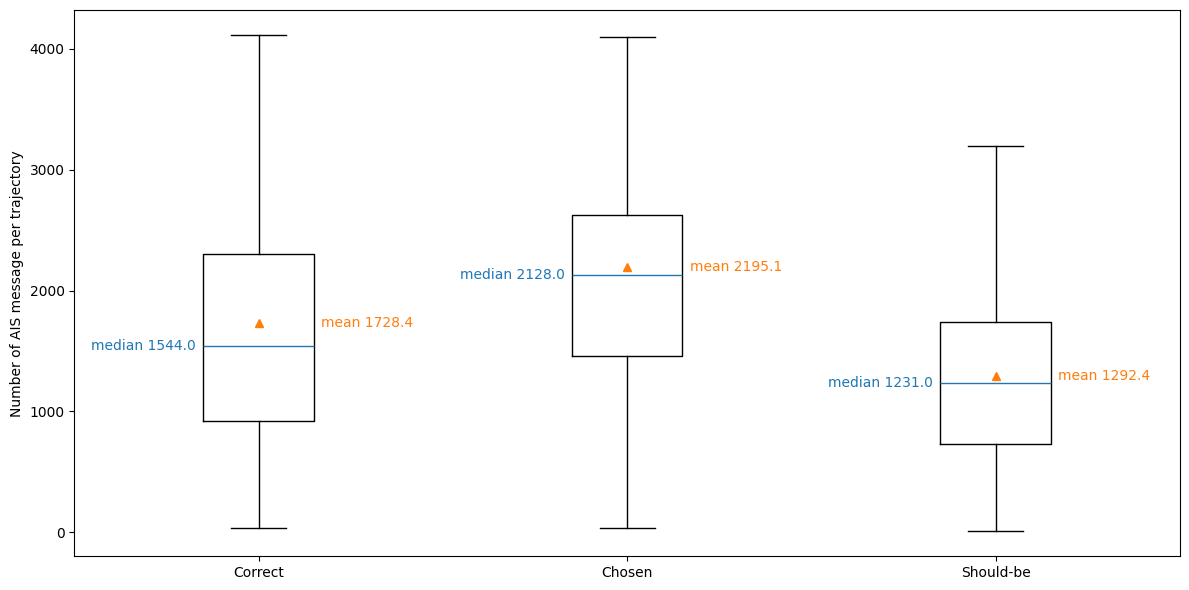

In [97]:
boxplot_track_length(df_correct_stats, df_incorrect_stats, df_shouldbe_stats)

In [22]:
df_correct_stats['#points'].var(), df_incorrect_stats['#points'].var(), df_shouldbe_stats['#points'].var() #equal variance assumption does not hold

(np.float64(1246207.0725045847),
 np.float64(1436430.035048564),
 np.float64(505379.6173238684))

Lets check the distribution of differences between incorrect and should be:

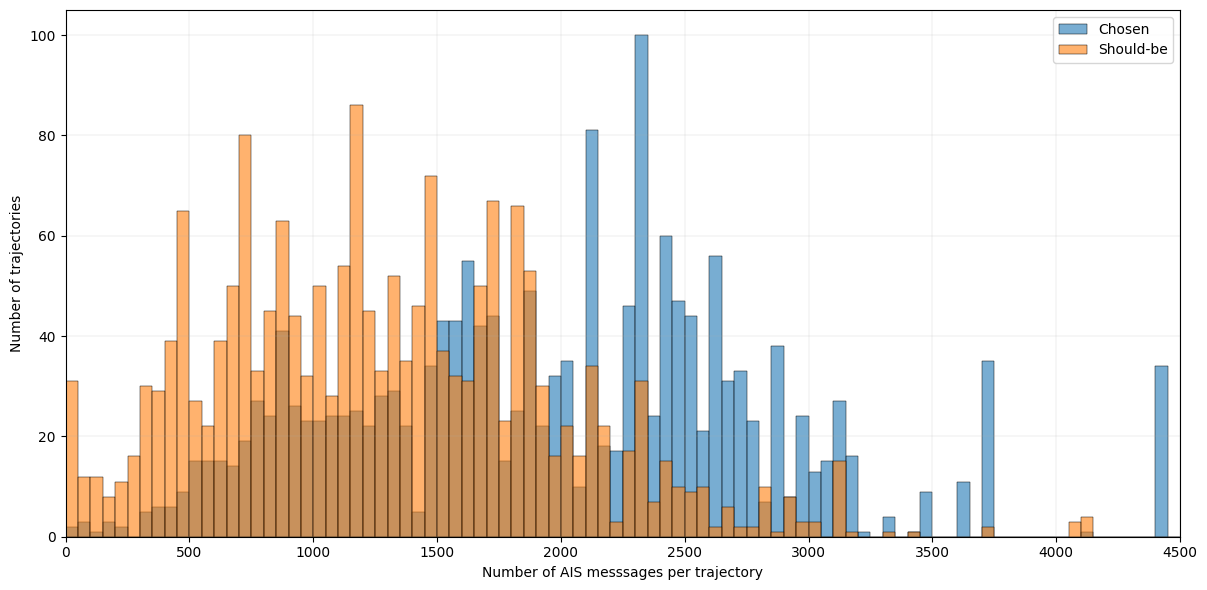

In [98]:
bins = range(0, 9100, 50) 
colors = sns.color_palette("viridis", 2)

plt.figure(figsize=(12, 6))
sns.histplot(df_incorrect_stats['#points'], bins=bins, alpha=0.6, label='Chosen', color="tab:blue")
sns.histplot(df_shouldbe_stats['#points'], bins=bins, alpha=0.6, label='Should-be', color="tab:orange")

plt.xlabel('Number of AIS messsages per trajectory')
plt.ylabel('Number of trajectories')
# plt.title('Comparison of AIS message counts: incorrectly chosen vs. correct should-be matches')
plt.legend()
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.xlim(0,4500)
plt.show()


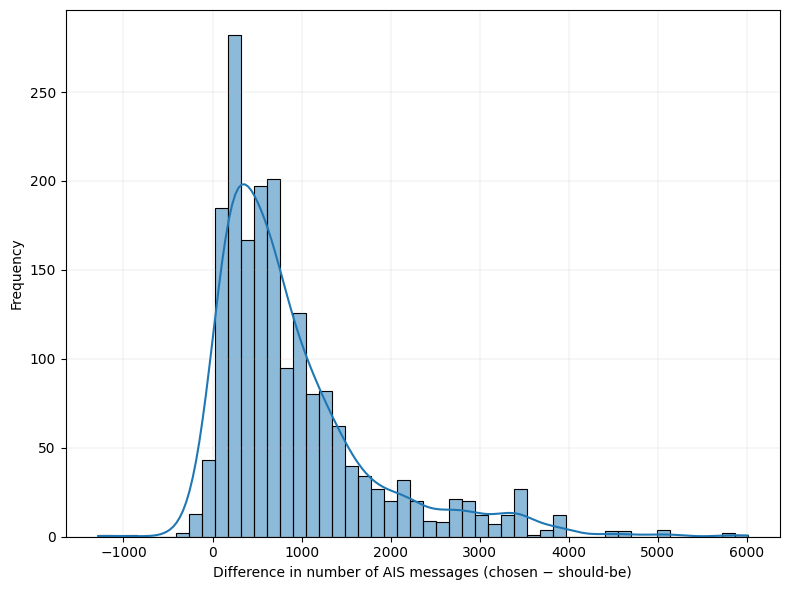

In [110]:
mean_error_nr_points = (df_incorrect_stats['#points'] - df_shouldbe_stats['#points']).mean()

plt.figure(figsize=(8, 6))
sns.histplot(df_incorrect_stats['#points'] - df_shouldbe_stats['#points'], bins=50, kde=True, color="tab:blue")
# plt.axvline(mean_error_nr_points, color="tab:orange", linestyle='--', label=f"Mean = {mean_error_nr_points:.0f} km")
# plt.title("Distribution of track length (incorrect - shouldbe)")
plt.xlabel("Difference in number of AIS messages (chosen − should-be)")
plt.ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

In [25]:
group1 = df_incorrect_stats['#points']     # incorrect chosen
group2 = df_shouldbe_stats['#points']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='greater')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect > shouldbe): {p_value:.10f}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")


t-statistic: 27.9105
one-sided p-value (H1: incorrect > shouldbe): 0.0000000000
H0 can be rejected


### __Correction on Track length (based on skewness previous graphs)__

#### Splitting RF point into test and validation set for correction hyperparameter tuning

In [26]:
def correct_forward_score(df_all_forward_results, df_AIS_stats, alpha : float):
    
    #haal algemene forward scores op per RF - AIS paardd
    forward_results = df_preselection_multimatch.merge(
        df_all_forward_results,    
        on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
        how='inner',
        suffixes=('', '_y')
    )
    forward_results.drop(forward_results.filter(regex='_y$').columns, axis=1, inplace=True)
    
    #add usuable precalculated stats
    all_tracks_stats = forward_results.merge(df_AIS_stats, left_on='AIS_track_id', right_on='ID', how='left')
    all_tracks_stats.drop(all_tracks_stats.filter(regex='_y$').columns, axis=1, inplace=True)

    #calculate wanted correction
    all_tracks_stats['normalized_forward_score_exp'] = all_tracks_stats['forward_score']/(all_tracks_stats['#points']**alpha)
    chosen = get_best_alignments(all_tracks_stats, "normalized_forward_score_exp")
    

    return calculate_metrics(chosen), chosen, all_tracks_stats


In [27]:
# Step 1: Create a list of all unique (RF_signal_id, RF_track_id) pairs
unique_rf_pairs = df_forward_results[["RF_signal_id", "RF_track_id"]].drop_duplicates()

# Step 2: Do the train/validation split on those pairs
train_pairs, val_pairs = train_test_split(unique_rf_pairs, test_size=0.2, random_state=100)

# Step 3: Merge to get the actual rows for each split
df_validation = df_forward_results.merge(val_pairs, on=["RF_signal_id", "RF_track_id"])
df_experiments = df_forward_results.merge(train_pairs, on=["RF_signal_id", "RF_track_id"])


In [28]:
alphas = np.arange(0.7, 1.3, 0.01)
results = {}

for alpha in alphas:
    alpha = round(alpha,2)
    precision, df, _ = correct_forward_score(df_validation, df_AIS_stats, alpha)

    results[alpha] = (precision['precision'])
    
best = sorted(results.items(), key=lambda x: x[1], reverse=True)[0]
print(f'Best alpha is {best[0]}, with a precision score of {best[1]}')

Best alpha is 0.87, with a precision score of 0.7975


In [29]:
metrics_exp , chosen_exp, all_tracks_stats = correct_forward_score(df_experiments, df_AIS_stats, 0.87)

best_chosen_exp = chosen_exp[chosen_exp['chosen']==True].reset_index(drop=True)
df_correct_exp = best_chosen_exp[
    best_chosen_exp["is_true_match"]
    ].sort_values(['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_incorrect_exp = best_chosen_exp[
    ~best_chosen_exp["is_true_match"]
    ].sort_values(['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_shouldbe_exp = (
    all_tracks_stats[all_tracks_stats["is_true_match"]]
    .merge(df_incorrect_exp[["RF_signal_id", "RF_track_id"]], 
           on=["RF_signal_id", "RF_track_id"], how="inner")
    ).sort_values(['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
print(metrics_exp)
print(len(chosen_exp))

{'precision': np.float64(0.7806), 'recall': np.float64(0.7806), 'f1_score': np.float64(0.7806), 'accuracy': np.float64(0.8349), 'TP': 3806, 'FP': 1070, 'FN': 1070, 'TN': 7017}
12963


Data zonder correctie ook bijwerken zodat alleen nog de RF punten uit de experimenten data overblijven

In [30]:
metrics , chosen, all_tracks_stats = correct_forward_score(df_experiments, df_AIS_stats, 1)

best_chosen = chosen[chosen['chosen']==True].reset_index(drop=True)
df_correct = best_chosen[best_chosen["is_true_match"]].sort_values(['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_incorrect = best_chosen[~best_chosen["is_true_match"]].sort_values(['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
df_shouldbe = (all_tracks_stats[all_tracks_stats["is_true_match"]]
    .merge(df_incorrect[["RF_signal_id", "RF_track_id"]], on=["RF_signal_id", "RF_track_id"], how="inner")).sort_values(['RF_signal_id', 'RF_track_id']).reset_index(drop=True)
print(metrics)
print(len(chosen))

{'precision': np.float64(0.6969), 'recall': np.float64(0.6969), 'f1_score': np.float64(0.6969), 'accuracy': np.float64(0.772), 'TP': 3398, 'FP': 1478, 'FN': 1478, 'TN': 6609}
12963


#### Comparison of validation set before and after correction

In [31]:
import pandas as pd

# Create confusion matrix as a DataFrame
conf_matrix = pd.DataFrame(
    [[metrics['TP'], metrics['FP']],
     [metrics['FN'], metrics['TN']]],
    index=["Actual Positive", "Actual Negative"],
    columns=["Predicted Positive", "Predicted Negative"]
)
print('Aantal rows:',len(df_experiments))
print("Confusion Matrix before correction:\n")
print(conf_matrix, "\n")
print("Performance Metrics before correction:\n")
print(f"Precision:  {metrics['precision']:.4f}")
print(f"Recall:     {metrics['recall']:.4f}")
print(f"F1 Score:   {metrics['f1_score']:.4f}")
print(f"Accuracy:   {metrics['accuracy']:.4f}")

Aantal rows: 12963
Confusion Matrix before correction:

                 Predicted Positive  Predicted Negative
Actual Positive                3398                1478
Actual Negative                1478                6609 

Performance Metrics before correction:

Precision:  0.6969
Recall:     0.6969
F1 Score:   0.6969
Accuracy:   0.7720


In [32]:
import pandas as pd

# Create confusion matrix as a DataFrame
conf_matrix = pd.DataFrame(
    [[metrics_exp['TP'], metrics_exp['FP']],
     [metrics_exp['FN'], metrics_exp['TN']]],
    index=["Actual Positive", "Actual Negative"],
    columns=["Predicted Positive", "Predicted Negative"]
)

print("Confusion Matrix after correction:\n")
print(conf_matrix, "\n")
print("Performance Metrics after correction:\n")
print(f"Precision:  {metrics_exp['precision']:.4f}")
print(f"Recall:     {metrics_exp['recall']:.4f}")
print(f"F1 Score:   {metrics_exp['f1_score']:.4f}")
print(f"Accuracy:   {metrics_exp['accuracy']:.4f}")


Confusion Matrix after correction:

                 Predicted Positive  Predicted Negative
Actual Positive                3806                1070
Actual Negative                1070                7017 

Performance Metrics after correction:

Precision:  0.7806
Recall:     0.7806
F1 Score:   0.7806
Accuracy:   0.8349


### __Experiment 1 (with correction)__

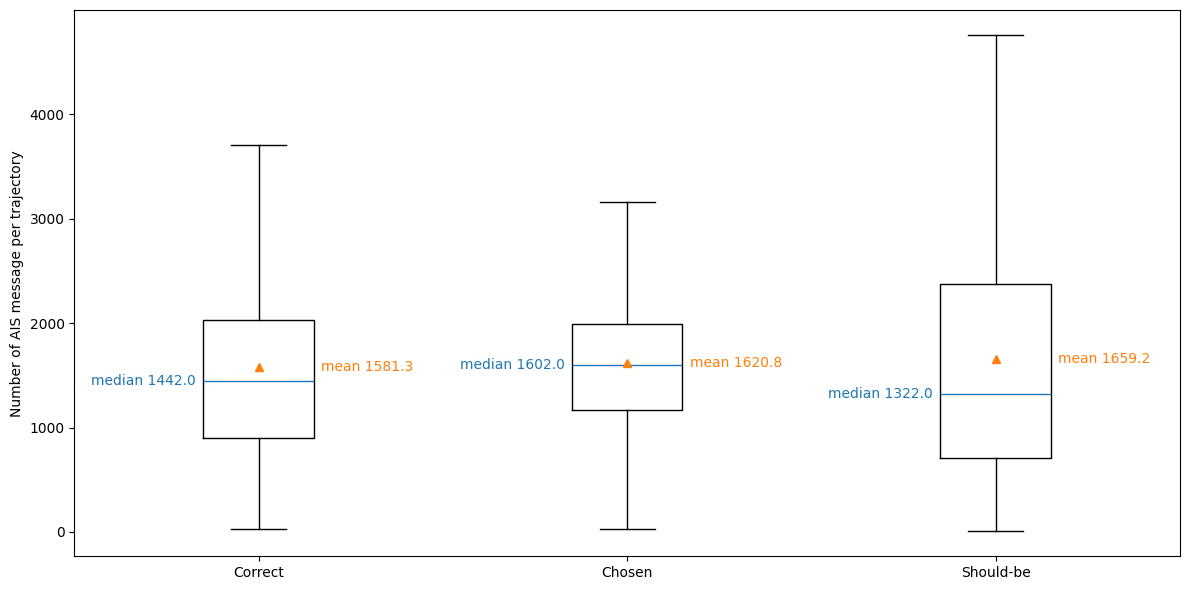

In [100]:
boxplot_track_length(df_correct_exp, df_incorrect_exp, df_shouldbe_exp)

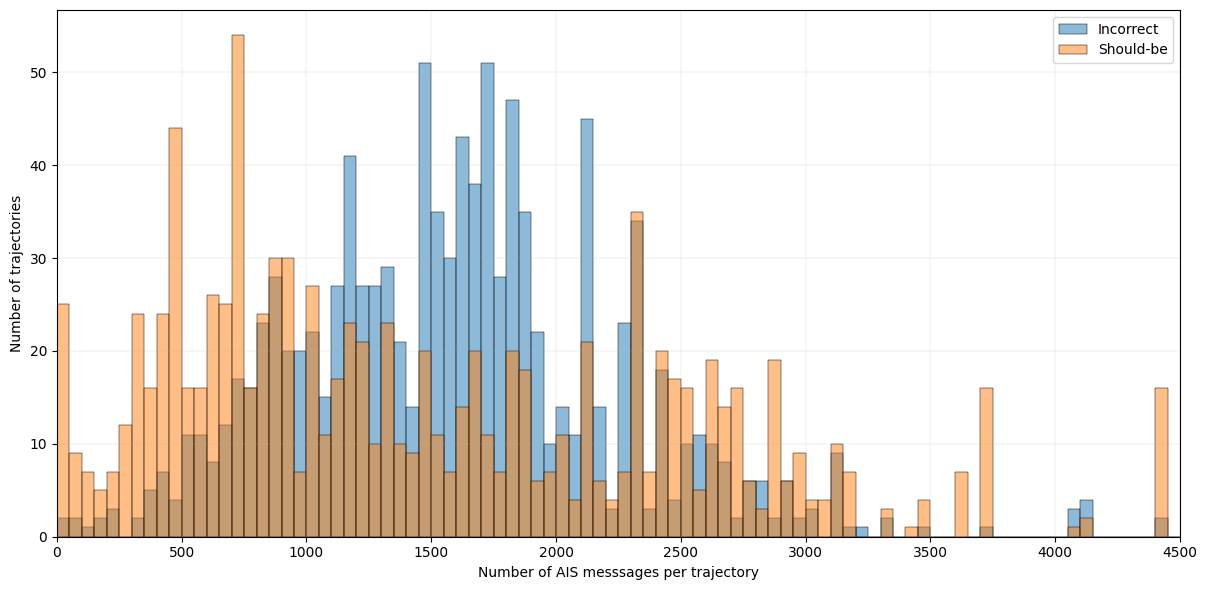

In [101]:
bins = range(0, 9100, 50) 

plt.figure(figsize=(12, 6))
sns.histplot(df_incorrect_exp['#points'], bins=bins, alpha=0.5, label='Incorrect')
sns.histplot(df_shouldbe_exp['#points'], bins=bins, alpha=0.5, label='Should-be')

plt.xlabel('Number of AIS messsages per trajectory')
plt.ylabel('Number of trajectories')
# plt.title('Comparison of AIS message counts: incorrectly chosen vs. correct should-me matches with correction')
plt.legend()
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.xlim(0,4500)
plt.show()


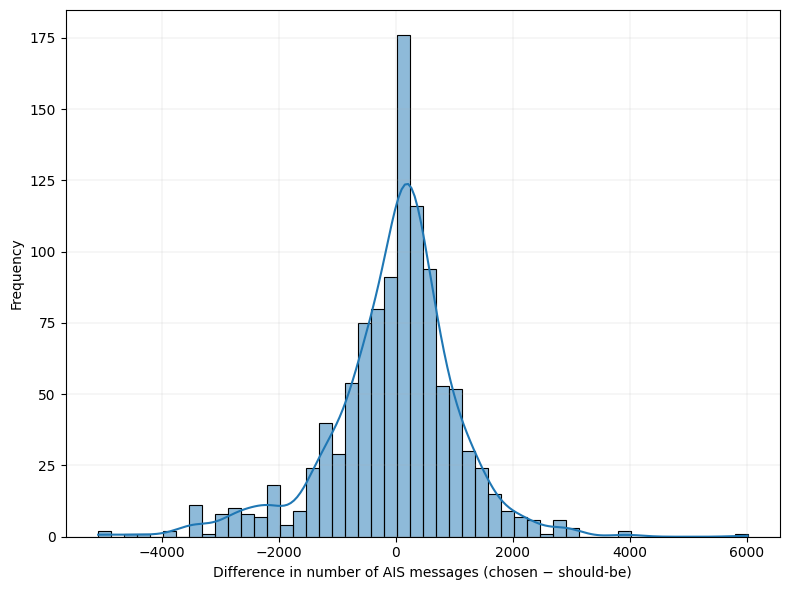

In [109]:
# mean_error_nr_points_exp = (df_incorrect_exp['#points'] - df_shouldbe_exp['#points']).mean()

plt.figure(figsize=(8, 6))

sns.histplot(df_incorrect_exp['#points'] - df_shouldbe_exp['#points'], bins=50, kde=True, color="tab:blue")
# plt.axvline(mean_error_nr_points_exp, color=colors[1], linestyle='--', label=f"Mean = {mean_error_nr_points_exp:.0f} km")
# plt.title("Distribution of track length (incorrect - shouldbe)")
plt.xlabel("Difference in number of AIS messages (chosen − should-be)")
plt.ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

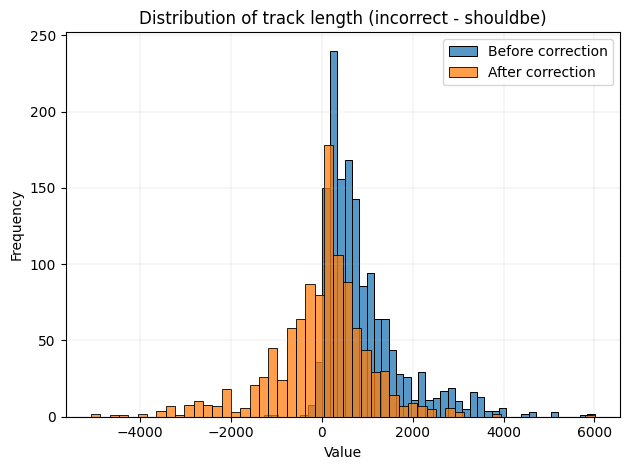

In [36]:
sns.histplot(df_incorrect['#points'] - df_shouldbe['#points'], label='Before correction', edgecolor='black', color="tab:blue")
sns.histplot(df_incorrect_exp['#points'] - df_shouldbe_exp['#points'], label='After correction', edgecolor='black', color="tab:orange")

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of track length (incorrect - shouldbe)")
plt.legend()
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

In [37]:
group1 = df_incorrect_exp['#points']     # incorrect chosen
group2 = df_shouldbe_exp['#points']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='greater')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect > should be): {p_value:.10f}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

t-statistic: -0.8581
one-sided p-value (H1: incorrect > should be): 0.8045169281
H0 cannot be rejected


In [38]:
group1 = df_incorrect_exp['#points']     # incorrect chosen
group2 = df_shouldbe_exp['#points']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='two-sided')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect > should be): {p_value:.10f}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

t-statistic: -0.8581
one-sided p-value (H1: incorrect > should be): 0.3909661439
H0 cannot be rejected


### __Experiment 2 (with correction)__

In [105]:
def boxplot_mean_intra_time(df_correct, df_chosen, df_shouldbe=None, column='mean_intra_time_diff'):
    """
    Creates a boxplot of mean_intra_time_diff for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    intra_correct = df_correct[column]
    intra_chosen  = df_chosen[column]

    data = [intra_correct, intra_chosen]
    labels = ['Correct', 'Chosen']

    if df_shouldbe is not None:
        intra_shouldbe = df_shouldbe[column]
        data.append(intra_shouldbe)
        labels.append('Should-be')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]
    
    meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True, medianprops=dict(color="tab:blue"), meanprops=meanpointprops)
    # ax.set_title('Mean intra-time difference: Correct vs Incorrect')
    ax.set_ylabel('Seconds')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.2f}", color = "tab:orange", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.2f}", color = "tab:blue", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [139]:
def histplot_intra_time_error(df_chosen, df_shouldbe):
    """
    Plots a histogram of the error in mean intra-time between
    incorrectly chosen and should-be AIS tracks.
    Includes a vertical line at the mean error.
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["intra_time_error"] = (
        df_merged["mean_intra_time_diff_chosen"] - 
        df_merged["mean_intra_time_diff_shouldbe"]
    )

    # mean_error = df_merged["intra_time_error"].mean()

    plt.figure(figsize=(8, 6))
    sns.histplot(df_merged["intra_time_error"], bins=50, kde=True, color="tab:blue")
    # plt.axvline(mean_error, color="#e14a5b", linestyle='--', label=f"Mean = {mean_error:.3f} sec")
    # plt.title("Histogram of Mean Intra-time Error (Chosen − Should-be)")
    plt.xlabel("Difference in mean-intra time (chosen − should-be)")
    plt.ylabel("Frequency")
    plt.grid(True, linewidth=0.15)
    plt.tight_layout()
    plt.show()


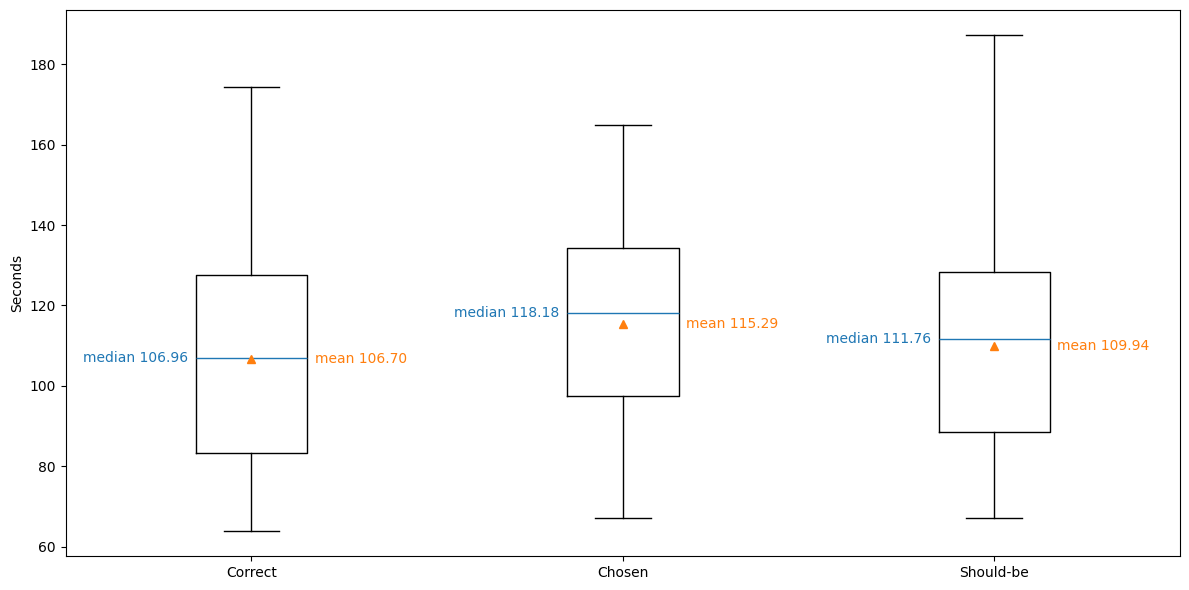

In [106]:
boxplot_mean_intra_time(df_correct_exp, df_incorrect_exp, df_shouldbe_exp)

In [42]:
# boxplot_mean_intra_time(df_correct_exp, df_incorrect_exp, df_shouldbe_exp, 'std_intra_time_diff')

In [43]:
# boxplot_mean_intra_time(df_correct_exp, df_incorrect_exp, df_shouldbe_exp, 'mean_transition_strength_corr')

In [44]:
# boxplot_mean_intra_time(df_correct_exp, df_incorrect_exp, df_shouldbe_exp, 'std_transition_strength')

In [45]:
# boxplot_mean_intra_time(df_correct_exp, df_incorrect_exp, df_shouldbe_exp, 'std_intra_dist_diff')

In [46]:
# boxplot_mean_intra_time(df_correct_exp, df_incorrect_exp, df_shouldbe_exp, 'mean_intra_dist_diff')

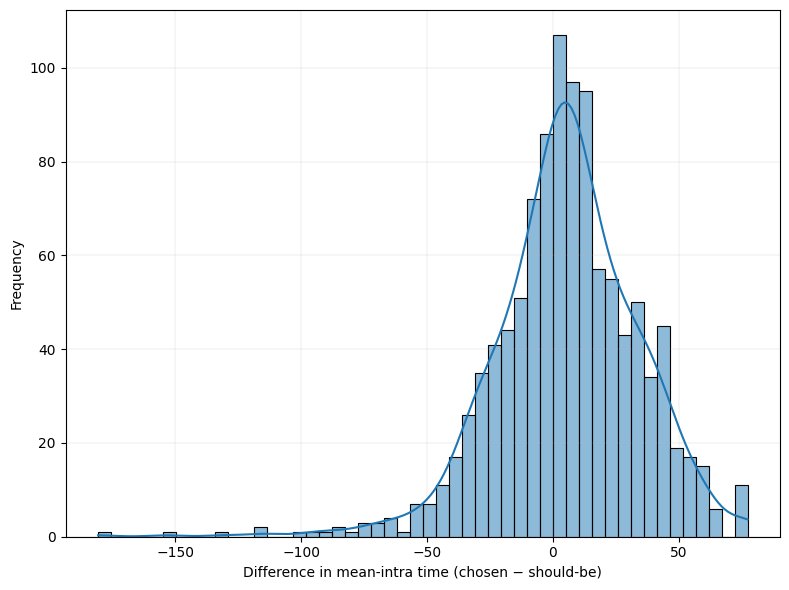

In [140]:
histplot_intra_time_error(df_incorrect_exp, df_shouldbe_exp)

In [48]:
group1 = df_incorrect_exp['mean_intra_time_diff']     # correct
group2 = df_shouldbe_exp['mean_intra_time_diff']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='less')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect < shouldbe): {p_value:.10f}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

t-statistic: 4.9702
one-sided p-value (H1: incorrect < shouldbe): 0.9999996385
H0 cannot be rejected


In [49]:
group1 = df_incorrect_exp['mean_intra_time_diff']     # correct
group2 = df_shouldbe_exp['mean_intra_time_diff']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='two-sided')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect < shouldbe): {p_value:.10f}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

t-statistic: 4.9702
one-sided p-value (H1: incorrect < shouldbe): 0.0000007229
H0 can be rejected


In [115]:
def boxplot_mean_intra_dist(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of compute_mean_intra_dist for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    intra_correct = df_correct['mean_intra_dist_diff']
    intra_chosen  = df_chosen['mean_intra_dist_diff']

    data = [intra_correct, intra_chosen]
    labels = ['Correct', 'Chosen']

    if df_shouldbe is not None:
        intra_shouldbe = df_shouldbe['mean_intra_dist_diff']
        data.append(intra_shouldbe)
        labels.append('Should-be')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]
    
    meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True, medianprops=dict(color="tab:blue"), meanprops=meanpointprops)

    # ax.set_title('Mean intra-distance difference: Correct vs Incorrect')
    ax.set_ylabel('Kilometers')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.3f}", color = "tab:orange", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.3f}", color = "tab:blue", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [141]:
def histplot_intra_dist_error(df_chosen, df_shouldbe):
    """
    Plots a histogram of the error in mean intra-time between
    incorrectly chosen and should-be AIS tracks.
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["intra_dist_error"] = (df_merged["mean_intra_dist_diff_chosen"] - df_merged["mean_intra_dist_diff_shouldbe"])
    
    # mean_error = df_merged["intra_dist_error"].mean()

    plt.figure(figsize=(8, 6))
    sns.histplot(df_merged["intra_dist_error"], bins=50, kde=True, color="tab:blue")
    # plt.axvline(mean_error, color="#e14a5b", linestyle='--', label=f"Mean = {mean_error:.2f} km")
    # plt.title("Histogram of mean intra-distance error (chosen − should-be)")
    plt.xlabel("Difference in mean intra-distance (chosen - should-be)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.grid(True, linewidth=0.15)
    plt.show()

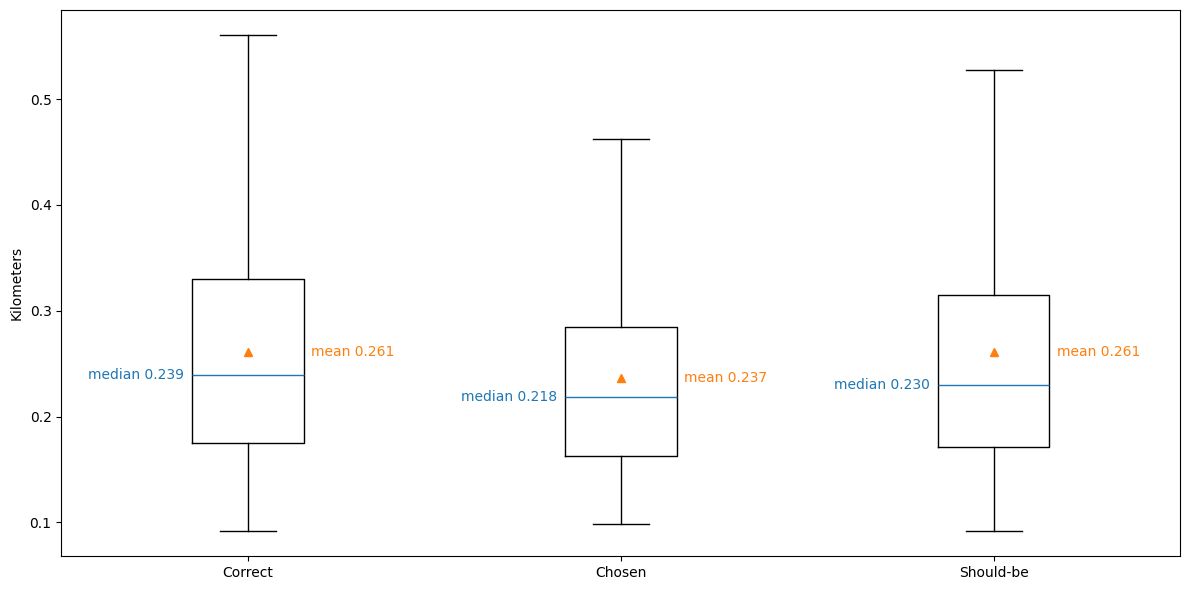

In [117]:
boxplot_mean_intra_dist(df_correct_exp, df_incorrect_exp, df_shouldbe_exp)

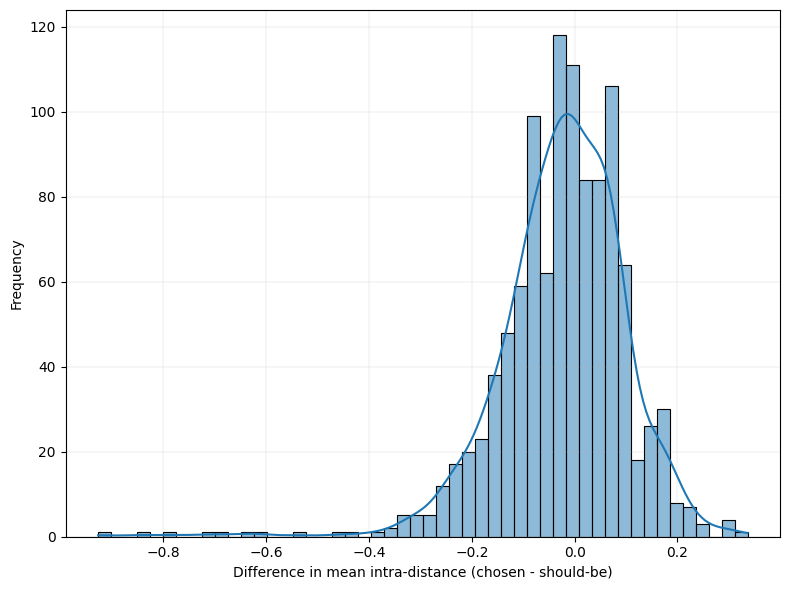

In [142]:
histplot_intra_dist_error(df_incorrect_exp, df_shouldbe_exp)

In [54]:
group1 = df_incorrect_exp['mean_intra_dist_diff']     # correct
group2 = df_shouldbe_exp['mean_intra_dist_diff']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='less')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect < shouldbe): {p_value:.10f}, {p_value:.3e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

t-statistic: -4.2665
one-sided p-value (H1: incorrect < shouldbe): 0.0000104229, 1.042e-05
H0 can be rejected


Intra distance difference lijkt niet heel veel invloed te hebben.

### __Experiment 3 (with correction)__

In [55]:
def compute_track_behavior(df, df_AIS, stationary_threshold = 5):
    """
    Adds per-track behavior statistics to the given dataframe
    """
    df_AIS = df_AIS.copy()
    df_AIS["is_stationary"] = df_AIS["speed_kph"] < stationary_threshold
    track_behavior_stats = (
        df_AIS
        .groupby("ID")
        .agg(
            stationary_ratio = ("is_stationary", "mean")
        )
        .reset_index()
        .set_index("ID")
    )
    return df.merge(track_behavior_stats, left_on = "AIS_track_id", right_on = "ID", how = "left")

In [121]:
def boxplot_track_behavior(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates boxplots for track-level behavior metrics:
    - stationary_ratio (proportion of time under threshold)
    """
    station_correct = df_correct['stationary_ratio']
    station_chosen  = df_chosen['stationary_ratio']

    stationary_data = [station_correct, station_chosen]
    labels = ['Correct', 'Chosen']

    if df_shouldbe is not None:
        station_shouldbe = df_shouldbe['stationary_ratio']
        stationary_data.append(station_shouldbe)
        labels.append('Should-be')

    station_means = [x.mean() for x in stationary_data]
    station_medians = [x.median() for x in stationary_data]

    meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(stationary_data, tick_labels=labels, showfliers=False, showmeans=True, medianprops=dict(color="tab:blue"), meanprops=meanpointprops)
    # ax.set_title("Stationary Behavior (stationary_ratio)")
    ax.set_ylabel("Proportion of Time Stationary (< 5 km/h)")

    for i, (m, med) in enumerate(zip(station_means, station_medians), start=1):
        ax.text(i + 0.17, m,   f"mean {m:.2f}", color="tab:orange", ha='left', va='center')
        ax.text(i - 0.17, med, f"median {med:.2f}", color="tab:blue", ha='right', va='center')

    plt.tight_layout()
    plt.show()


In [122]:
def histplot_track_behavior_errors(df_chosen, df_shouldbe):
    """
    Plots histograms of the errors between incorrectly chosen and should-be AIS tracks
    for:
    - std_speed_kph (speed variability)
    - stationary_ratio (proportion of time under threshold)
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["stationary_error"] = (df_merged["stationary_ratio_chosen"] - df_merged["stationary_ratio_shouldbe"])

    fig, ax = plt.subplots(figsize=(12, 6))

    sns.histplot(df_merged["stationary_error"], bins=50, kde=True, ax=ax)
    # ax[1].set_title("Stationary ratio error (chosen − should-be)")
    ax[1].set_xlabel("Difference in stationary ratio (chosen - should-be)")
    ax[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


In [58]:
df_correct_exp = compute_track_behavior(df_correct_exp, df_AIS)
df_incorrect_exp = compute_track_behavior(df_incorrect_exp, df_AIS)
df_shouldbe_exp = compute_track_behavior(df_shouldbe_exp, df_AIS)

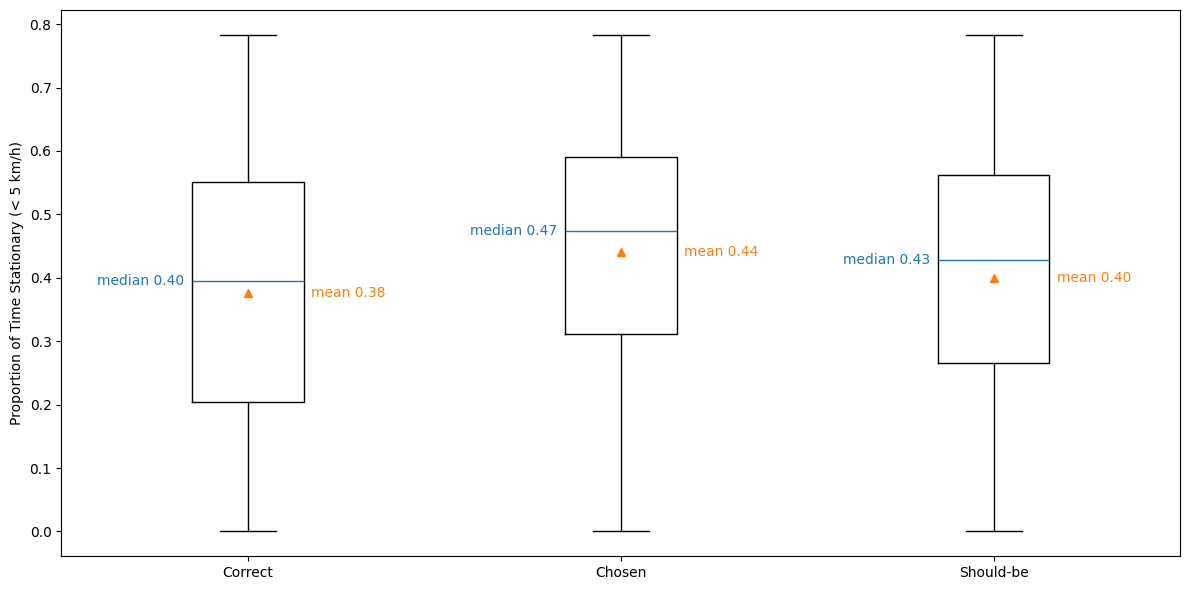

In [123]:
boxplot_track_behavior(df_correct_exp, df_incorrect_exp, df_shouldbe_exp)

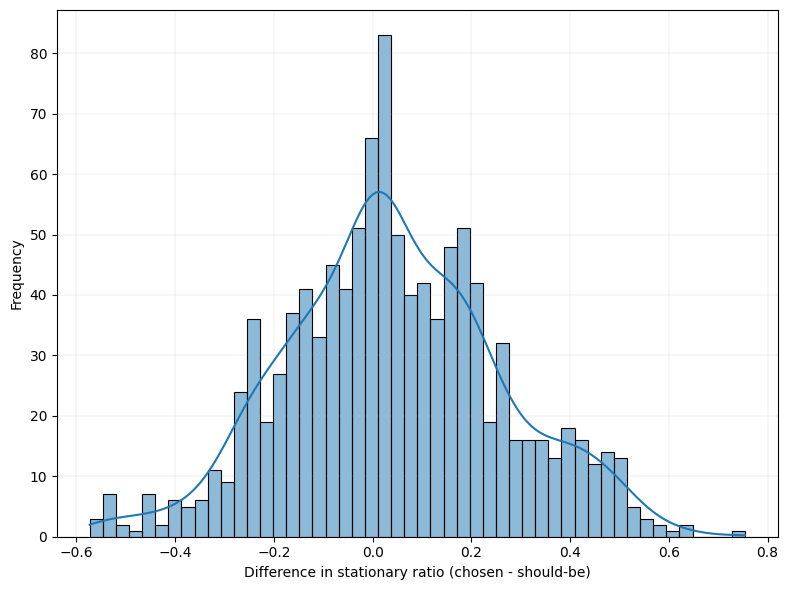

In [125]:
plt.figure(figsize=(8, 6))
sns.histplot(df_incorrect_exp["stationary_ratio"] - df_shouldbe_exp["stationary_ratio"], bins=50, kde=True, color="tab:blue")
# plt.title("Stationary ratio error (incorrect - shouldbe)")
plt.xlabel("Difference in stationary ratio (chosen - should-be)")
plt.ylabel("Frequency")
plt.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

In [61]:
group1 = df_incorrect_exp['stationary_ratio']     # correct
group2 = df_shouldbe_exp['stationary_ratio']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='greater')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect > shouldbe): {p_value:.10f}, {p_value:.3e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

t-statistic: 5.0395
one-sided p-value (H1: incorrect > shouldbe): 0.0000002530, 2.530e-07
H0 can be rejected


### __Experiment 4 (with correction)__

##### Difference in distance and time between correct and incorrect (chosen) matches

In [65]:
def compute_time_dist_diff(df_best, df_train, suffix=""):
    # Make RF dataframe
    df_RF = df_train[df_train["RF"].notna()].copy()
    df_RF = df_RF[["ID", "RF_Timestamp", "RF"]]
    df_RF["RF_signal_id"] = df_RF.groupby("ID").cumcount() + 1

    # Merge RF with best alignments 
    df_merged = df_best.merge(df_RF.rename({"ID": "RF_track_id"}, axis=1), on=["RF_signal_id", "RF_track_id"], how="left")

    # Make AIS dataframe
    df_AIS = df_train[df_train["AIS"].notna()].copy()
    df_AIS_grouped = df_AIS.groupby("ID")
    
    if suffix != "":
        suffix = f"_{suffix}"

    # Function
    def compute_diffs(row):
        seq = df_AIS_grouped.get_group(row["AIS_track_id"])
        AIS_time, AIS_coords = min(
            zip(seq["AIS_Timestamp"], seq["AIS"]), 
            key=lambda x: abs(x[0] - row["RF_Timestamp"]).total_seconds())
            
        time_diff = abs((row["RF_Timestamp"] - AIS_time).total_seconds())
        distance_diff = haversine(row["RF"], AIS_coords)
            
        return pd.Series({
            f"AIS_Timestamp{suffix}": AIS_time,
            f"AIS{suffix}": AIS_coords,
            f"time_diff{suffix}": time_diff, 
            f"distance_diff{suffix}": distance_diff
            })
        
    cols = [
        f"AIS_Timestamp{suffix}", 
        f"AIS{suffix}", 
        f"time_diff{suffix}", 
        f"distance_diff{suffix}"
    ]
        
    df_merged[cols] = df_merged.apply(compute_diffs, axis=1)
    return df_merged

In [129]:
def boxplot_time_dist_diff(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates boxplots of time_diff and distance_diff for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    time_correct = df_correct['time_diff']
    time_chosen = df_chosen['time_diff']
    dist_correct = df_correct['distance_diff']
    dist_chosen = df_chosen['distance_diff']

    data_time = [time_correct, time_chosen]
    data_dist = [dist_correct, dist_chosen]
    labels = ['Correct', 'Chosen']

    if df_shouldbe is not None:
        time_shouldbe = df_shouldbe['time_diff']
        dist_shouldbe = df_shouldbe['distance_diff']
        data_time.append(time_shouldbe)
        data_dist.append(dist_shouldbe)
        labels.append('Should-be')

    mean_time = [x.mean() for x in data_time]
    med_time = [x.median() for x in data_time]
    mean_dist = [x.mean() for x in data_dist]
    med_dist = [x.median() for x in data_dist]

    # Time difference boxplot
    
    meanpointprops = dict(marker='^', markerfacecolor='tab:orange', markeredgecolor='tab:orange')

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(data_time, tick_labels=labels, showfliers=False, showmeans=True, medianprops=dict(color="tab:blue"), meanprops=meanpointprops)
    # ax.set_title('Time difference (without outliers)')
    ax.set_ylabel('Seconds')
    for i, (mean, median) in enumerate(zip(mean_time, med_time), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color='tab:orange', ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color='tab:blue', ha='right', va='center')

    # Distance difference boxplot
    # ax.boxplot(data_dist, tick_labels=labels, showfliers=False, showmeans=True, medianprops=dict(color="tab:blue"), meanprops=meanpointprops)
    # # ax.set_title('Distance difference (without outliers)')
    # ax.set_ylabel('Kilometers')
    
    # for i, (mean, median) in enumerate(zip(mean_dist, med_dist), start=1):
    #     ax.text(i + 0.17, mean, f"mean {mean:.1f}", color='tab:orange', ha='left', va='center')
    #     ax.text(i - 0.17, median, f"median {median:.1f}", color='tab:blue', ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [145]:
def histplot_time_dist_error(df_chosen, df_shouldbe):
    """
    Maakt histogrammen van de fout in tijd en afstand
    tussen incorrect gekozen match en de correcte (should-be).
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["time_error"] = df_merged["time_diff_chosen"] - df_merged["time_diff_shouldbe"]
    df_merged["distance_error"] = df_merged["distance_diff_chosen"] - df_merged["distance_diff_shouldbe"]

    fig, ax = plt.subplots(figsize=(12, 6))

    # Time error
    sns.histplot(df_merged["time_error"], bins=100, kde=True, ax=ax, color="tab:blue")
    # ax.set_title("Histogram of time error (chosen − should-be)")
    ax.set_xlabel("Difference in distance (chosen - should-be)")
    ax.set_ylabel("Frequency")
    plt.grid(True, linewidth=0.15)

    # # Distance error
    # sns.histplot(df_merged["distance_error"], bins=100, kde=True, ax=ax, color="tab:blue")
    # # ax.set_title("Histogram of distance error (chosen − should-be)")
    # ax.set_xlabel("Difference in distance (chosen - should-be)")
    # ax.set_ylabel("Frequency")
    # plt.grid(True, linewidth=0.15)

    plt.tight_layout()
    plt.show()

### Experiment results voor matches met correctie

In [68]:
df_incorrect_exp = compute_time_dist_diff(df_incorrect_exp, df_train_set)
df_shouldbe_exp = compute_time_dist_diff(df_shouldbe_exp, df_train_set)
df_correct_exp = compute_time_dist_diff(df_correct_exp, df_train_set)

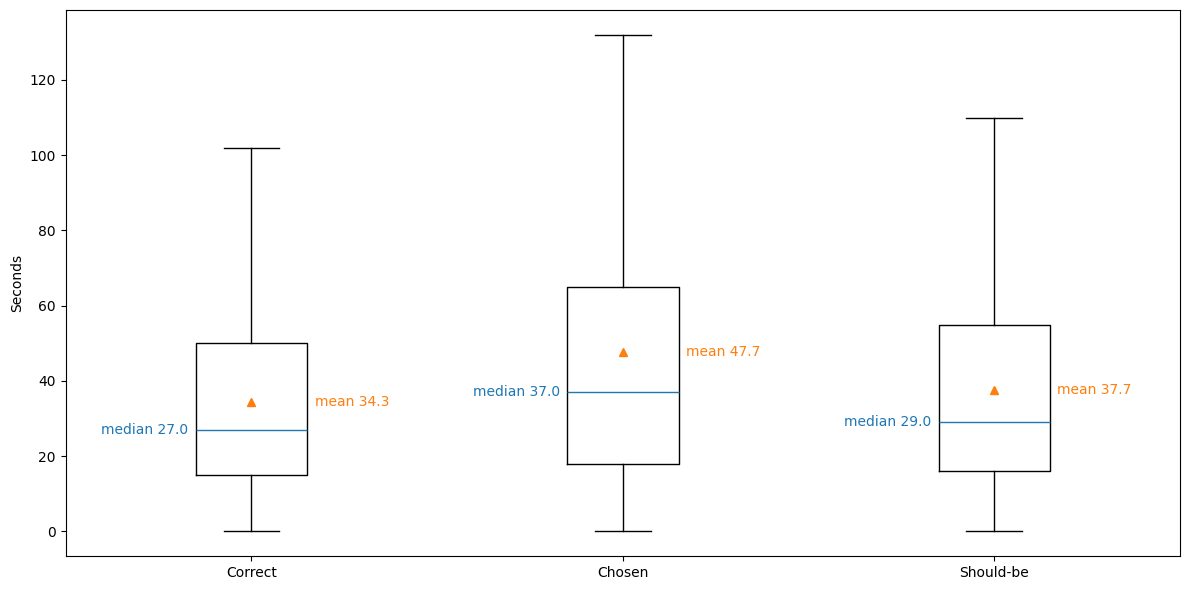

In [130]:
boxplot_time_dist_diff(df_correct_exp, df_incorrect_exp, df_shouldbe_exp)

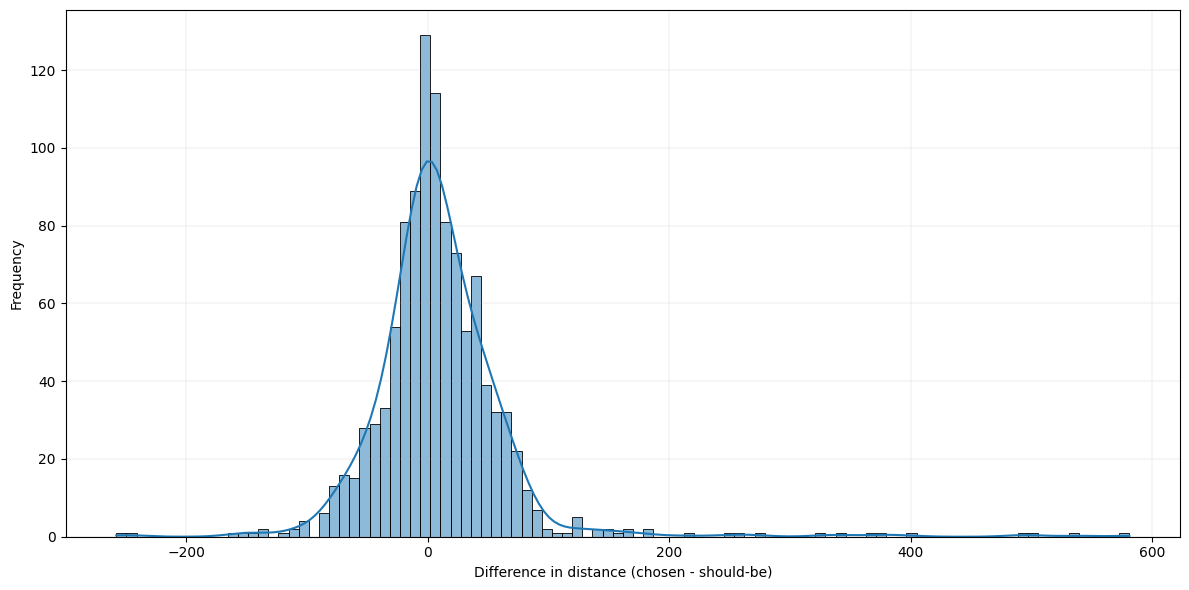

In [146]:
histplot_time_dist_error(df_incorrect_exp, df_shouldbe_exp)

In [ ]:
group1 = df_incorrect_exp['time_diff']     # correct
group2 = df_shouldbe_exp['time_diff']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='less')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect < shouldbe): {p_value:.10f}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

t-statistic: 5.1435
one-sided p-value (H1: incorrect < shouldbe): 0.9999998494
H0 cannot be rejected


In [ ]:
group1 = df_incorrect_exp['time_diff']     # correct
group2 = df_shouldbe_exp['time_diff']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='two-sided')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect < shouldbe): {p_value:.10f}, {p_value:.3e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

t-statistic: 5.1435
one-sided p-value (H1: incorrect < shouldbe): 0.0000003011, 3.011e-07
H0 can be rejected


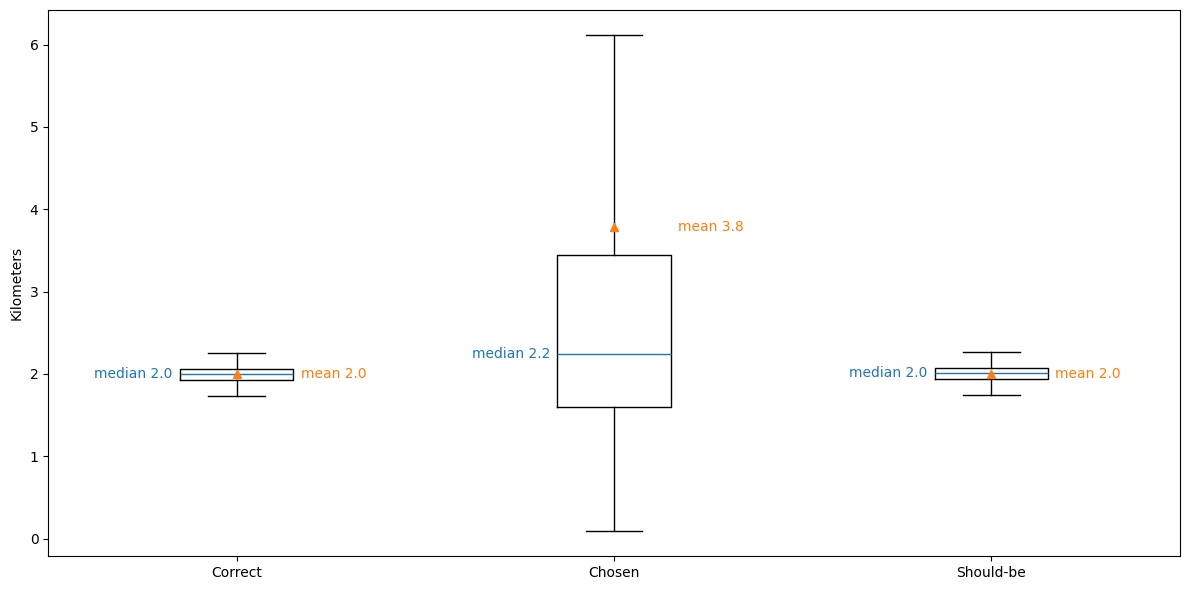

In [128]:
boxplot_time_dist_diff(df_correct_exp, df_incorrect_exp, df_shouldbe_exp)

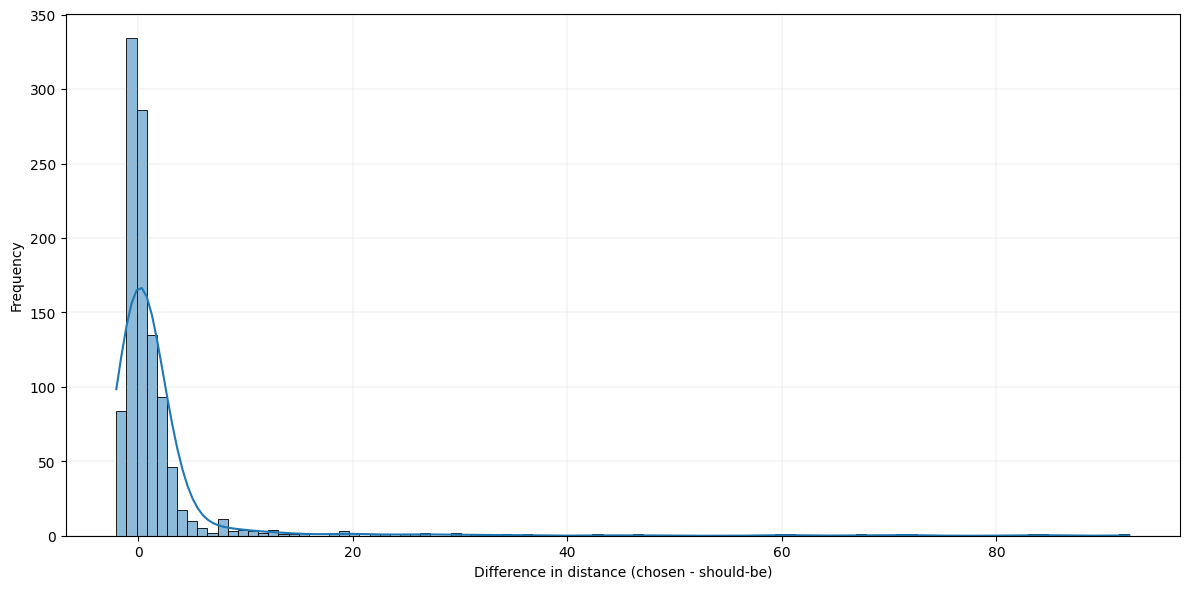

In [144]:
histplot_time_dist_error(df_incorrect_exp, df_shouldbe_exp)

In [ ]:
group1 = df_incorrect_exp['distance_diff']     # correct
group2 = df_shouldbe_exp['distance_diff']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='less')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect < shouldbe): {p_value:.10f}, {p_value:.3e}")

if p_value < 0.05:
    print("H0 can be rejected")
else:
    print("H0 cannot be rejected")

t-statistic: 7.6423
one-sided p-value (H1: incorrect not < shouldbe): 1.0000000000, 1.000e+00
H0 cannot be rejected


In [ ]:
dist_diff = df_incorrect_exp['distance_diff'] - df_shouldbe_exp['distance_diff']
np.sum(dist_diff > 0),np.sum(dist_diff < 0),np.sum(dist_diff == 0)

time_diff = df_incorrect_exp['time_diff'] - df_shouldbe_exp['time_diff']
np.sum(time_diff > 0),np.sum(time_diff < 0),np.sum(time_diff == 0)

(np.int64(621), np.int64(448), np.int64(1))

In [308]:
# Boolean masks
time_neg = time_diff < 0
dist_neg = dist_diff < 0

# Beide < 0
both_neg = np.sum(time_neg & dist_neg)

# Alleen tijd < 0
time_only_neg = np.sum(time_neg & ~dist_neg)

# Alleen afstand < 0
dist_only_neg = np.sum(~time_neg & dist_neg)

# Rest (geen van beide < 0)
rest = np.sum(~time_neg & ~dist_neg)

# Omzetten naar percentages
total = len(time_diff)
both_neg_pct = both_neg / total * 100
time_only_neg_pct = time_only_neg / total * 100
dist_only_neg_pct = dist_only_neg / total * 100
rest_pct = rest / total * 100

both_neg_pct, time_only_neg_pct, dist_only_neg_pct, rest_pct


(np.float64(19.439252336448597),
 np.float64(23.738317757009344),
 np.float64(22.429906542056074),
 np.float64(34.39252336448598))

In [310]:
df_incorrect_exp[time_neg & dist_neg]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,chosen,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight,normalized_forward_score_exp,std_speed_kph,stationary_ratio,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,match_possible
4,1,"(244109000, 3)","(477287000, 23)",False,-47.652462,-0.029163,-0.061117,True,"(477287000, 23)",1634,3036.183333,11.839035,2.49878,1.95735,111.556032,63.596273,0.236956,0.193875,0.634287,0.104837,0.793264,0.070840,-0.236167,0.099409,8.515435,8.405269,-0.076306,8.800979,0.343329,2024-01-04 11:40:10,"[30.72305355369483, -88.04457621872623]",2024-01-04 11:39:06,"[30.72098, -88.0426]",64.0,0.298073,True
44,1,"(338058000, 7)","(352002338, 73)",False,-61.077687,-0.028541,-0.061448,True,"(352002338, 73)",2140,3590.583333,14.186327,4.87895,1.72598,100.717625,56.254306,0.284058,0.196045,0.648604,0.094056,0.802848,0.063557,-0.223266,0.089860,10.396654,13.452479,-0.077343,8.731356,0.266822,2024-01-24 15:27:16,"[39.265281785068574, -76.56603611879842]",2024-01-24 15:28:18,"[39.26209, -76.57204]",62.0,0.627002,True
55,1,"(355981000, 38)","(241821000, 22)",False,-24.310410,-0.036230,-0.069461,True,"(241821000, 22)",671,1415.633333,8.401811,0.59261,0.65622,126.773134,62.684317,0.161934,0.195448,0.613841,0.110397,0.780136,0.072314,-0.252834,0.097016,6.043486,4.530677,-0.084439,9.779142,0.575261,2024-01-26 23:08:37,"[29.35203648533225, -89.50849716211451]",2024-01-26 23:08:19,"[29.35549, -89.51094]",18.0,0.451132,True
58,1,"(366906610, 2)","(368183000, 2)",False,-55.889006,-0.028720,-0.061249,True,"(368183000, 2)",1946,3609.283333,11.866023,0.56751,5.61651,111.340360,60.986306,0.228203,0.179619,0.634777,0.100333,0.793959,0.066372,-0.234549,0.089726,11.074511,15.936749,-0.076873,9.292347,0.379753,2024-01-04 08:26:02,"[47.03216387801994, -91.67800280038209]",2024-01-04 08:26:00,"[47.01495, -91.67137]",2.0,1.979029,True
63,1,"(367147480, 52)","(375902000, 71)",False,-35.358845,-0.031263,-0.063151,True,"(375902000, 71)",1131,1786.933333,20.509662,0.56925,4.23589,94.881416,60.428966,0.418744,0.252438,0.640413,0.099871,0.797081,0.071242,-0.231814,0.106573,9.329790,10.303128,-0.077980,9.520463,0.173298,2024-01-12 15:27:16,"[18.31673246625897, -64.94823581264704]",2024-01-12 15:27:24,"[18.33538, -64.94944]",8.0,2.077406,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,25,"(215804000, 8)","(257242000, 3)",False,-45.544319,-0.029270,-0.061042,True,"(257242000, 3)",1556,3034.050000,15.123279,2.99933,2.11307,117.069453,63.702446,0.283618,0.275926,0.611985,0.096443,0.779597,0.064915,-0.252822,0.090397,9.348484,10.351391,-0.076100,14.349085,0.447943,2024-01-05 08:26:02,"[39.232708851255296, -76.55118850389286]",2024-01-05 08:25:27,"[39.24164, -76.53533]",35.0,1.688688,True
1046,28,"(215804000, 8)","(257242000, 3)",False,-45.508186,-0.029247,-0.060993,True,"(257242000, 3)",1556,3034.050000,15.123279,2.99933,2.11307,117.069453,63.702446,0.283618,0.275926,0.611985,0.096443,0.779597,0.064915,-0.252822,0.090397,9.348484,10.351391,-0.076040,14.349085,0.447943,2024-01-05 19:11:03,"[39.24447485247779, -76.552738418182]",2024-01-05 19:10:30,"[39.24165, -76.5353]",33.0,1.534246,True
1051,29,"(368270390, 0)","(538010162, 7)",False,-31.746717,-0.031683,-0.063229,True,"(538010162, 7)",1002,2302.083333,9.402753,0.69397,0.40879,137.987013,67.562407,0.197395,0.308508,0.585625,0.109220,0.761484,0.075937,-0.278351,0.114519,7.745476,6.933530,-0.077794,11.770056,0.601796,2024-01-05 02:07:00,"[29.316972147314154, -94.81789335692368]",2024-01-05 02:05:48,"[29.30869, -94.81331]",72.

In [316]:
AIS_filtered = df_AIS[df_AIS["ID"].isin([(244109000, 3), ])]
RF_filtered = df_train_set[(df_train_set["ID"]== (244109000, 3)) & (~df_train_set["RF"].isna())].iloc[0]

In [314]:
# Initialize the interactive map
map_center = [AIS_filtered["LAT"].mean(), AIS_filtered["LON"].mean()]
map = folium.Map(location=map_center, zoom_start=7, tiles="CartoDB Positron")

# Kleuren per SubTrackID
unique_ids = AIS_filtered["track_id"].unique()
colors = ["#e14a5b", "#117b88", "#9dc6ce", "#f46d43", "#fee08b"]
color_map = {track_id: colors[i % len(colors)] for i, track_id in enumerate(unique_ids)}

# Plot AIS route
ais_layer = folium.FeatureGroup(name="AIS Tracks")
for (mmsi, track_id), group in AIS_filtered.groupby("ID"):
    color = color_map[track_id]
    for _, row in group.iterrows():
        heading = 315 + row['Heading']
        icon_html = f'''
            <div style="font-size:12px; transform: rotate({heading}deg);">
                <i class="fa-solid fa-location-arrow" style="color: {color};"></i>
            </div>
            '''
        folium.Marker(
            location=(row['LAT'], row['LON']),
            tooltip=f"AIS Point\nMMSI: {mmsi}\nTrack: {track_id}\nTime: {row['BaseDateTime']}",
            icon=folium.DivIcon(html=icon_html)
        ).add_to(ais_layer)
ais_layer.add_to(map)

# Plot RF signals
rf_layer = folium.FeatureGroup(name="RF Signals")
track_id = RF_filtered["track_id"]
color = "blue"
icon_html = f'''
    <i class="fa-solid fa-star" style="color: {color};"></i>
    '''
folium.Marker(
    location=RF_filtered["RF"],
    tooltip=f"RF signal: {RF_filtered['RF_Timestamp']}",
    icon=folium.DivIcon(html=icon_html),
).add_to(rf_layer)
rf_layer.add_to(map)

folium.LayerControl(collapsed=False).add_to(map)
map

In [307]:
time_diff = df_incorrect_exp['time_diff'] - df_shouldbe_exp['time_diff']
np.sum(time_diff > 0),np.sum(time_diff < 0),np.sum(time_diff == 0)

(np.int64(596), np.int64(462), np.int64(12))

Voor de zekerheid two-sided t-test tussendoor om te checken op uberhaupt effect

In [212]:
from scipy.stats import ttest_ind

# Define your two groups
group1 = df_incorrect_exp['time_diff']     # correct
group2 = df_shouldbe_exp['time_diff']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='greater')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect > shouldbe): {p_value:.10f}")

t-statistic: 5.1435
one-sided p-value (H1: incorrect > shouldbe): 0.0000001506


De omgekeerde t-test laat zien dat het model zelfs een "voorkeur" zou hebben voor slechtere RF matches. Aangezien dit niet in de aard van het model ligt moet het effect veroorzaakt worden door andere factoren.

Conclusie: 

Time difference error: 

- De overgrote meerderheid zit binnen +- 2 minuten tussen gekozen en juiste match
- Er zijn enkele uitschieters waarbij de gekozen match veel later valt dan de juiste match

Distance difference error: 

- In bijna alle gevallen ligt de gekozen match qua afstand verder weg dan de juiste
- In een klein aantal gevallen wijken de gekozen en juiste match extreem af (niet perse erg toch?)

### Experiment 5, verschil in forwardscore en length ratio

er zit weinig echte verschillen tussen mean intra time en dist diff, dus waar komen dan de verkeerde matches vandaan? Heeft het dan alsnog iets met length te maken ondanks de correctie?

<Axes: xlabel='normalized_forward_score_exp', ylabel='Count'>

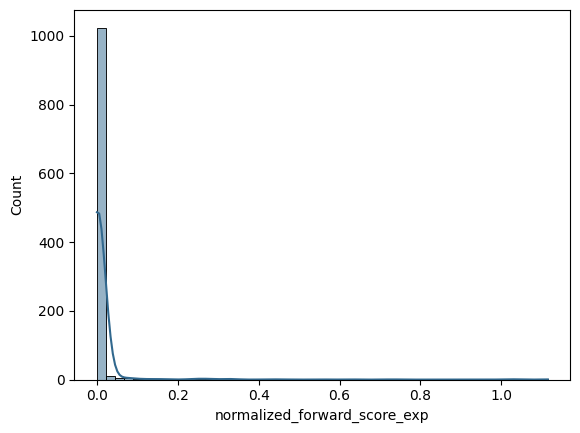

In [213]:
sns.histplot(df_incorrect_exp['normalized_forward_score_exp'] - df_shouldbe_exp['normalized_forward_score_exp'], bins=50, kde=True, color=colors[0])

In [214]:
pd.set_option('display.max_columns', None)

In [215]:
df_shouldbe_exp["mean_intra_time_diff"].mean()

np.float64(109.94435559699859)

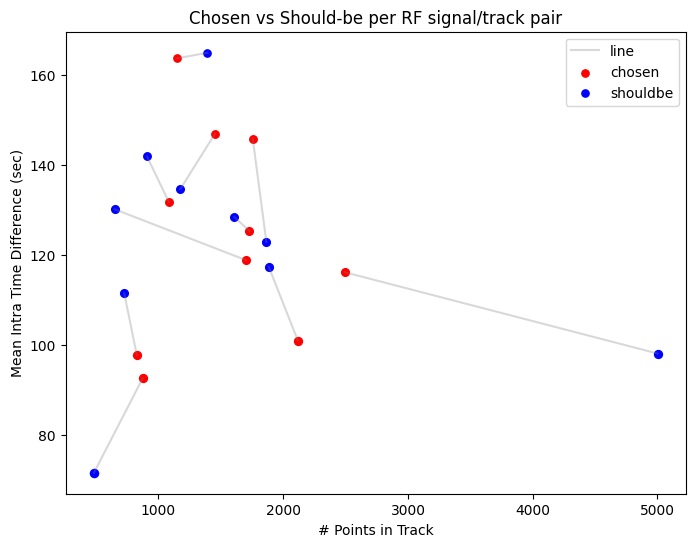

In [236]:
plt.figure(figsize=(8,6))

# Maak een lijst van unieke combinaties
unique_pairs = df_incorrect_exp[['RF_signal_id', 'RF_track_id']].drop_duplicates()
sample_pairs = unique_pairs.sample(n=10, random_state=42)

for _, row in sample_pairs.iterrows():
    rf_signal = row['RF_signal_id']
    rf_track = row['RF_track_id']
    
    chosen_row = df_incorrect_exp[
        (df_incorrect_exp['RF_signal_id'] == rf_signal) &
        (df_incorrect_exp['RF_track_id'] == rf_track)
    ].iloc[0]
    
    shouldbe_row = df_shouldbe_exp[
        (df_shouldbe_exp['RF_signal_id'] == rf_signal) &
        (df_shouldbe_exp['RF_track_id'] == rf_track)
    ].iloc[0]
    
    # Lijn tussen chosen en should-be
    plt.plot(
        [chosen_row['#points'], shouldbe_row['#points']],
        [chosen_row['mean_intra_time_diff'], shouldbe_row['mean_intra_time_diff']],
        c='gray', alpha=0.3
    )
    
    # Chosen
    plt.scatter(
        chosen_row['#points'],
        chosen_row['mean_intra_time_diff'],
        s=chosen_row['mean_transition_strength']*50,
        c='red'
    )
    
    # Should-be
    plt.scatter(
        shouldbe_row['#points'],
        shouldbe_row['mean_intra_time_diff'],
        s=shouldbe_row['mean_transition_strength']*50,
        c='blue'
    )


plt.xlabel("# Points in Track")
plt.ylabel("Mean Intra Time Difference (sec)")
plt.title("Chosen vs Should-be per RF signal/track pair")
plt.legend(["line", "chosen", "shouldbe"])
plt.show()


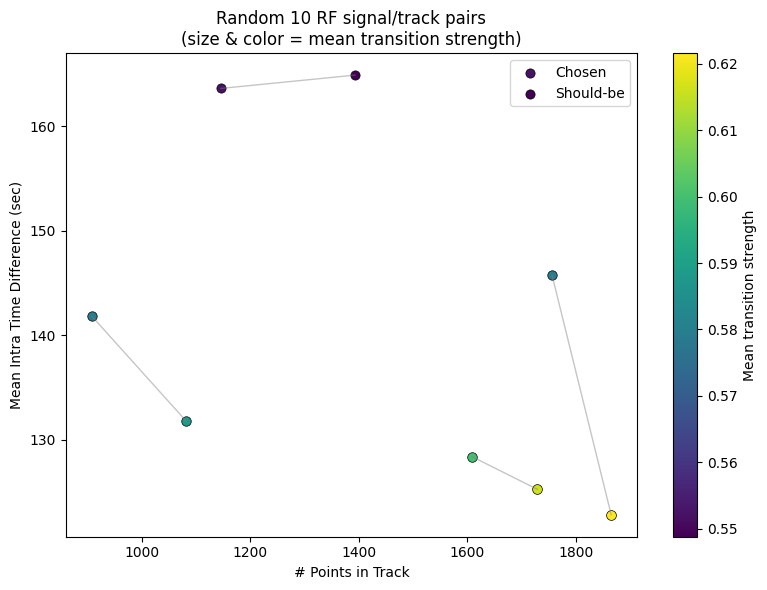

In [237]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Unieke combinaties
unique_pairs = df_incorrect_exp[['RF_signal_id', 'RF_track_id']].drop_duplicates()

# Random 10 kiezen
sample_pairs = unique_pairs.sample(n=4, random_state=42)

# Voor consistente kleur-schaal: alle waarden vooraf verzamelen
vals = []
for _, row in sample_pairs.iterrows():
    rf_signal, rf_track = row['RF_signal_id'], row['RF_track_id']
    mt_c = df_incorrect_exp[(df_incorrect_exp['RF_signal_id']==rf_signal)&(df_incorrect_exp['RF_track_id']==rf_track)]['mean_transition_strength'].iloc[0]
    mt_s = df_shouldbe_exp[(df_shouldbe_exp['RF_signal_id']==rf_signal)&(df_shouldbe_exp['RF_track_id']==rf_track)]['mean_transition_strength'].iloc[0]
    vals.extend([mt_c, mt_s])

vmin, vmax = np.nanmin(vals), np.nanmax(vals)

# Plot
first = True
scatters = []
for _, row in sample_pairs.iterrows():
    rf_signal, rf_track = row['RF_signal_id'], row['RF_track_id']

    chosen_row = df_incorrect_exp[(df_incorrect_exp['RF_signal_id']==rf_signal)&(df_incorrect_exp['RF_track_id']==rf_track)].iloc[0]
    shouldbe_row = df_shouldbe_exp[(df_shouldbe_exp['RF_signal_id']==rf_signal)&(df_shouldbe_exp['RF_track_id']==rf_track)].iloc[0]

    # Lijn tussen chosen en should-be
    plt.plot(
        [chosen_row['#points'],  shouldbe_row['#points']],
        [chosen_row['mean_intra_time_diff'], shouldbe_row['mean_intra_time_diff']],
        c='gray', alpha=0.45, linewidth=1
    )

    # Chosen punt (kleur + grootte = mean_transition_strength)
    sc1 = plt.scatter(
        chosen_row['#points'],
        chosen_row['mean_intra_time_diff'],
        c=[chosen_row['mean_transition_strength']],
        s=max(20, chosen_row['mean_transition_strength']*80),
        cmap='viridis', vmin=vmin, vmax=vmax,
        edgecolors='k', linewidths=0.5,
        label='Chosen' if first else None
    )
    # Should-be punt
    sc2 = plt.scatter(
        shouldbe_row['#points'],
        shouldbe_row['mean_intra_time_diff'],
        c=[shouldbe_row['mean_transition_strength']],
        s=max(20, shouldbe_row['mean_transition_strength']*80),
        cmap='viridis', vmin=vmin, vmax=vmax,
        marker='o', edgecolors='k', linewidths=0.5,
        label='Should-be' if first else None
    )
    first = False
    scatters = [sc1, sc2]

# Colorbar voor mean transition strength
cbar = plt.colorbar(scatters[0])
cbar.set_label("Mean transition strength")

plt.xlabel("# Points in Track")
plt.ylabel("Mean Intra Time Difference (sec)")
plt.title("Random 10 RF signal/track pairs\n(size & color = mean transition strength)")
plt.legend(loc='best')
plt.tight_layout()
plt.show()



In [220]:
sample_pairs

,RF_signal_id,RF_track_id
644,8,"(311001247, 4)"
629,8,"(209850000, 3)"
70,1,"(367781630, 67)"
962,16,"(477308400, 0)"


In [221]:
df_shouldbe_exp[(df_shouldbe_exp["RF_signal_id"] == 16	) & (df_shouldbe_exp["RF_track_id"] == (477308400, 0))]['normalized_forward_score_exp'], df_incorrect_exp[(df_incorrect_exp["RF_signal_id"] == 16) & (df_incorrect_exp["RF_track_id"] == (477308400, 0))]['normalized_forward_score_exp']

(962   -0.07757
 Name: normalized_forward_score_exp, dtype: float64,
 962   -0.077452
 Name: normalized_forward_score_exp, dtype: float64)

In [222]:
df_incorrect_exp[(df_incorrect_exp["RF_signal_id"] == 16) & (df_incorrect_exp["RF_track_id"] == (477308400, 0))]['normalized_forward_score_exp']

962   -0.077452
Name: normalized_forward_score_exp, dtype: float64

In [223]:
-0.07757 < -0.077452

True

In [224]:
df_incorrect_exp_smaller = df_incorrect_exp[length_ratio < 1]
df_ishouldbe_exp_larger = df_shouldbe_exp[length_ratio < 1]

df_incorrect_exp_larger = df_incorrect_exp[length_ratio > 1]
df_ishouldbe_exp_smaller = df_shouldbe_exp[length_ratio > 1]

(-6000.0, 6000.0)

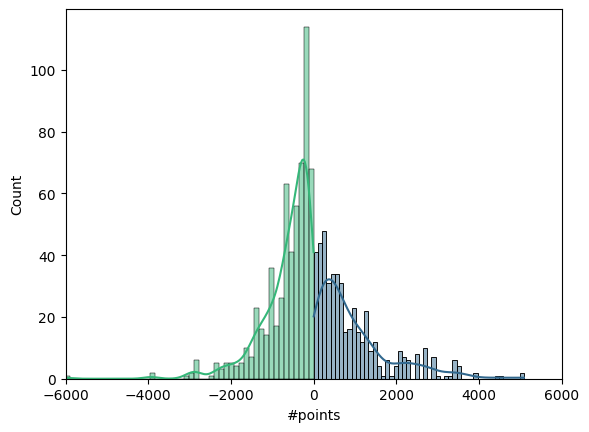

In [225]:
df_ishouldbe_exp_larger = df_shouldbe_exp[length_ratio < 1]
    
sns.histplot(df_ishouldbe_exp_larger['#points'] - df_incorrect_exp_smaller['#points'], bins=50, kde=True, color=colors[0])
sns.histplot(df_ishouldbe_exp_smaller['#points'] - df_incorrect_exp_larger['#points'], bins=50, kde=True, color=colors[1])
plt.xlim(-6000,6000)



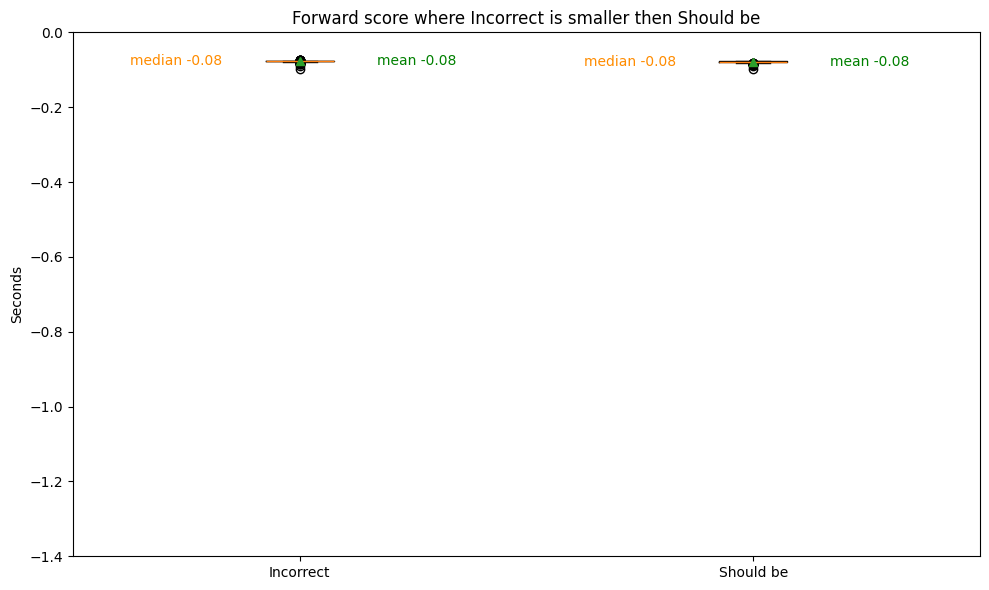

In [ ]:
intra_correct = df_incorrect_exp_smaller['normalized_forward_score_exp']
intra_chosen  = df_ishouldbe_exp_larger['normalized_forward_score_exp']

data = [intra_correct, intra_chosen]
labels = ['Incorrect', 'Should be']

means = [x.mean() for x in data]
medians = [x.median() for x in data]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data, tick_labels=labels, showfliers=True, showmeans=True)
ax.set_title('Forward score where Incorrect is smaller then Should be')
ax.set_ylabel('Forward score')

for i, (mean, median) in enumerate(zip(means, medians), start=1):
    ax.text(i + 0.17, mean, f"mean {mean:.2f}", color = "green", ha='left', va='center')
    ax.text(i - 0.17, median, f"median {median:.2f}", color = "darkorange", ha='right', va='center')
    
plt.ylim(-1.4,0)

plt.tight_layout()
plt.show()

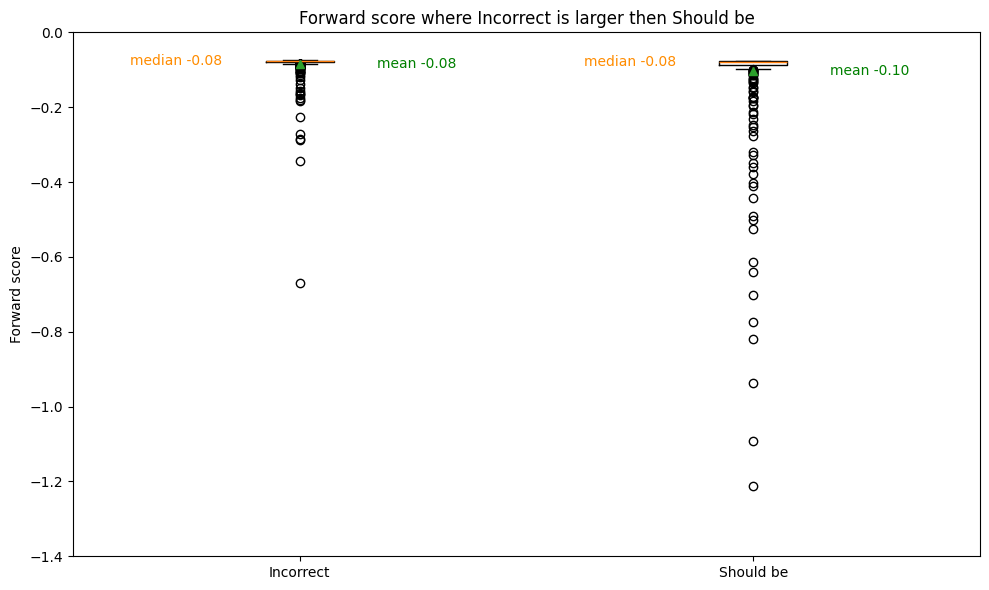

In [248]:
intra_correct = df_incorrect_exp_larger['normalized_forward_score_exp']
intra_chosen  = df_ishouldbe_exp_smaller['normalized_forward_score_exp']

data = [intra_correct, intra_chosen]
labels = ['Incorrect', 'Should be']

means = [x.mean() for x in data]
medians = [x.median() for x in data]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data, tick_labels=labels, showfliers=True, showmeans=True)
ax.set_title('Forward score where Incorrect is larger then Should be')
ax.set_ylabel('Forward score')

for i, (mean, median) in enumerate(zip(means, medians), start=1):
    ax.text(i + 0.17, mean, f"mean {mean:.2f}", color = "green", ha='left', va='center')
    ax.text(i - 0.17, median, f"median {median:.2f}", color = "darkorange", ha='right', va='center')
    
plt.ylim(-1.4,0)

plt.tight_layout()
plt.show()

In [249]:
# Define your two groups
group1 = df_incorrect_exp_larger['normalized_forward_score_exp']     # correct
group2 = df_ishouldbe_exp_smaller['normalized_forward_score_exp']      # should-be chosen

# Perform Welch’s t-test with one-sided alternative
t_stat, p_value = ttest_ind(group1, group2, equal_var=False, alternative='greater')

print(f"t-statistic: {t_stat:.4f}")
print(f"one-sided p-value (H1: incorrect > shouldbe): {p_value:.10f}")

t-statistic: 4.2980
one-sided p-value (H1: incorrect > shouldbe): 0.0000098495


Pearson correlation coefficient: 0.7951
P-value: 0.0000000000
The correlation is statistically significant.


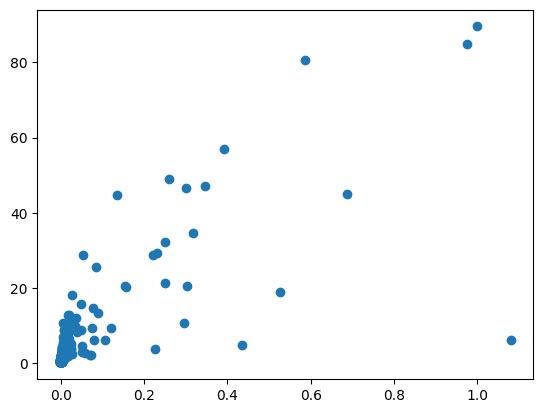

In [229]:
plt.scatter(score_diff,length_ratio)

from scipy.stats import pearsonr

# Pearson correlation
corr_coef, p_value = pearsonr(score_diff, length_ratio)

print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.10f}")

if p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")


In [230]:
#alles waarbij shouldbe 10 keer zo groot is al incorrect chosen -> blijft miniem verschil in forward score
#alles waarbij incorrect 10 keer zo groot is als shouldbe -> veel groter verschil in forward score

1070


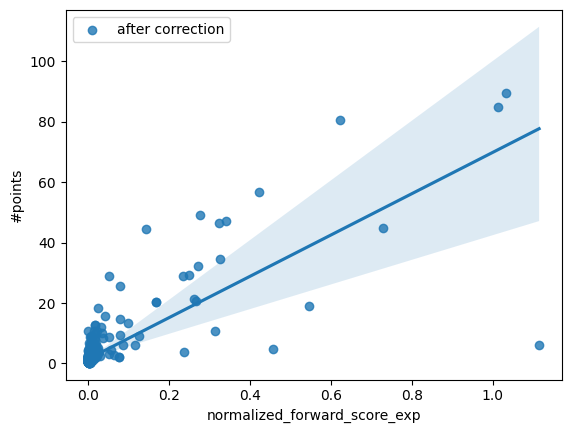

In [277]:
score_diff_exp = df_incorrect_exp['normalized_forward_score_exp'] - df_shouldbe_exp['normalized_forward_score_exp']
length_ratio_exp = df_incorrect_exp['#points'] / df_shouldbe_exp['#points']
print(len(score_diff_exp))
sns.regplot(x=score_diff_exp, y=length_ratio_exp, label='after correction')
plt.legend()


1478


<Axes: xlabel='normalized_forward_score', ylabel='#points'>

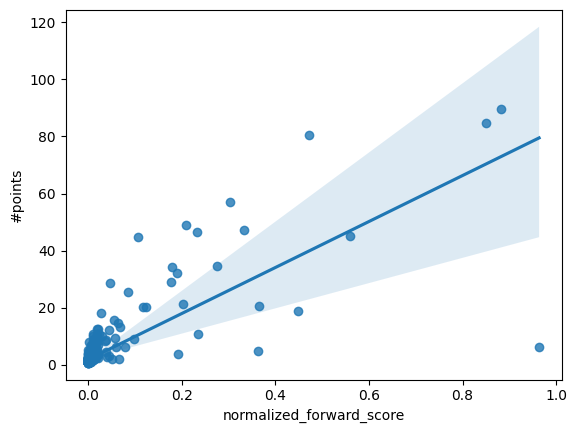

In [ ]:
score_diff = df_incorrect['normalized_forward_score'] - df_shouldbe['normalized_forward_score']
length_ratio = df_incorrect['#points'] / df_shouldbe['#points']
print(len(score_diff))

sns.regplot(x=score_diff, y=length_ratio,label='pre correction')

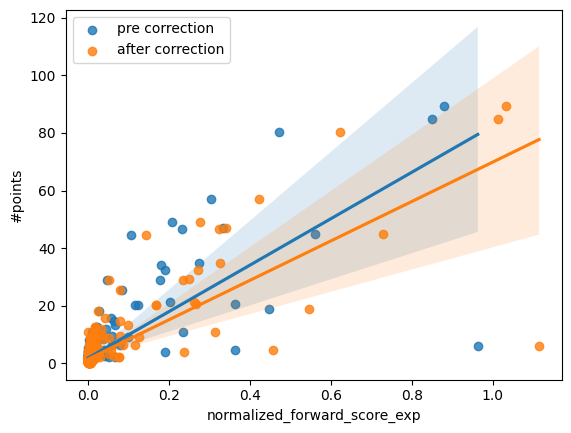

In [ ]:
sns.regplot(x=score_diff, y=length_ratio,label='pre correction')
sns.regplot(x=score_diff_exp, y=length_ratio_exp,label='after correction')
plt.legend()

In [281]:
df_incorrect_exp.iloc[[length_ratio_exp.idxmax()]]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,chosen,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight,normalized_forward_score_exp,std_speed_kph,stationary_ratio,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,match_possible
6,1,"(246263000, 72)","(477027300, 204)",False,-42.627865,-0.079381,-0.148839,True,"(477027300, 204)",537,682.733333,24.544625,2.02298,1.15258,76.425373,25.726056,0.519116,0.165842,0.658948,0.068049,0.810358,0.047636,-0.212466,0.070643,6.262863,4.7861,-0.179728,1.33782,0.0,2024-01-25 15:27:16,"[24.670144808543466, -79.740940463387]",2024-01-25 15:27:16,"[24.42339, -80.09625]",0.0,45.214751,False


In [282]:
df_shouldbe_exp.iloc[[length_ratio_exp.idxmax()]]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,chosen,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight,normalized_forward_score_exp,std_speed_kph,stationary_ratio,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,match_possible
6,1,"(246263000, 72)","(246263000, 72)",True,-5.763068,-0.960511,-1.148994,False,"(246263000, 72)",6,7.683333,18.556504,0.01134,0.01992,92.2,22.785961,0.475091,0.116601,0.690086,0.165001,0.826228,0.086221,-0.196002,0.099634,3.646329,2.488256,-1.212445,0.060111,0.0,2024-01-25 15:27:16,"[24.670144808543466, -79.740940463387]",2024-01-25 15:27:19,"[24.66677, -79.76063]",3.0,2.024653,False


0.88113

In [299]:
df_incorrect_exp.iloc[[126]]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,chosen,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight,normalized_forward_score_exp,std_speed_kph,stationary_ratio,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,match_possible
126,1,"(636021579, 10)","(636021579, 11)",False,-14.968523,-0.035303,-0.064647,True,"(636021579, 11)",424,496.7,29.050451,1.34281,2.03802,70.453901,18.653034,0.566522,0.134834,0.66251,0.057495,0.813031,0.038614,-0.208305,0.053595,7.447191,6.435296,-0.077512,1.63501,0.0,2024-01-01 15:27:16,"[33.661214450114755, -76.57984258381026]",2024-01-01 15:36:32,"[33.67981, -76.53375]",556.0,4.740211,False


In [ ]:
df_shouldbe_exp.iloc[[126]]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,chosen,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight,normalized_forward_score_exp,std_speed_kph,stationary_ratio,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,match_possible
126,1,"(636021579, 10)","(636021579, 10)",True,-4.426855,-0.885371,-1.039974,False,"(636021579, 10)",5,12.3,26.506837,0.03057,0.04557,184.5,87.736347,1.354545,0.633441,0.502214,0.310668,0.682215,0.191823,-0.422682,0.286499,3.989327,2.711039,-1.091419,0.248373,0.0,2024-01-01 15:27:16,"[33.661214450114755, -76.57984258381026]",2024-01-01 15:22:33,"[33.64379, -76.58487]",283.0,1.992611,False


-0.100347

In [300]:
df_incorrect_exp.iloc[[60]]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,chosen,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight,normalized_forward_score_exp,std_speed_kph,stationary_ratio,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,match_possible
60,1,"(367147480, 26)","(375902000, 32)",False,-33.330157,-0.031864,-0.063864,True,"(375902000, 32)",1046,1861.666667,14.1696,0.26002,1.19338,106.889952,60.37663,0.274167,0.205117,0.636366,0.096975,0.795111,0.06453,-0.232936,0.08821,8.175567,7.720598,-0.078676,10.584352,0.347992,2024-01-05 15:27:16,"[18.3103109665127, -64.94529176622326]",2024-01-05 15:28:17,"[18.3354, -64.94942]",61.0,2.823606,False


In [301]:
df_shouldbe_exp.iloc[[60]]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,chosen,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,std_intra_time_diff,mean_intra_dist_diff,std_intra_dist_diff,mean_transition_strength,std_transition_strength,mean_transition_strength_corr,std_transition_strength_corr,mean_transition_strength_log,std_transition_strength_log,density_score,sampling_weight,normalized_forward_score_exp,std_speed_kph,stationary_ratio,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,match_possible
60,1,"(367147480, 26)","(367147480, 26)",True,-6.541795,-0.503215,-0.650351,False,"(367147480, 26)",13,26.033333,7.005456,0.02361,0.01437,130.166667,112.873085,0.282518,0.319073,0.649962,0.197152,0.79333,0.143492,-0.25532,0.241118,4.832932,3.347564,-0.70237,3.352815,0.230769,2024-01-05 15:27:16,"[18.3103109665127, -64.94529176622326]",2024-01-05 15:26:19,"[18.32302, -64.95773]",57.0,1.929,True


In [297]:
sorted(dict(length_ratio_exp).items(), key=lambda x: x[1], reverse=True)[:3]

[(6, np.float64(89.5)),
 (126, np.float64(84.8)),
 (60, np.float64(80.46153846153847))]